<a href="https://colab.research.google.com/github/garnfelfel/Deep_Learning_Homeworks/blob/main/ctcbeamTreansformer_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip cache purge
!pip uninstall numpy
!pip install numpy pyctcdecode jiwer huggingface_hub https://github.com/kpu/kenlm/archive/master.zip Levenshtein cer wer

Files removed: 0
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Would remove:
    /usr/local/bin/f2py
    /usr/local/bin/numpy-config
    /usr/local/lib/python3.12/dist-packages/numpy-2.0.2.dist-info/*
    /usr/local/lib/python3.12/dist-packages/numpy.libs/libgfortran-040039e1-0352e75f.so.5.0.0
    /usr/local/lib/python3.12/dist-packages/numpy.libs/libquadmath-96973f99-934c22de.so.0.0.0
    /usr/local/lib/python3.12/dist-packages/numpy.libs/libscipy_openblas64_-99b71e71.so
    /usr/local/lib/python3.12/dist-packages/numpy/*
Proceed (Y/n)? Y
  Successfully uninstalled numpy-2.0.2
     - 553.6 kB 9.3 MB/s 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 66.7 MB

In [1]:
from google.colab import drive
import math
from typing import Dict, Tuple, List, Any, Optional
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import Levenshtein                 # pip: python-Levenshtein
from jiwer import wer              # pip: jiwer
from cer import calculate_cer      # pip: cer
from torch.utils.data import Dataset, DataLoader
import kenlm
from glob import glob
import numpy as np
from pyctcdecode import build_ctcdecoder
from tqdm import tqdm
import matplotlib.pyplot as plt


In [2]:
# Try clean unmount (ignore errors if already unmounted)
try:
    drive.flush_and_unmount()
except Exception as e:
    print("flush_and_unmount error:", e)

# Remount
drive.mount('/content/drive', force_remount=True)

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [3]:
# Create a mapping from characters to unique integer IDs for the CTC vocabulary.
# <BLANK> is reserved for the CTC blank symbol. Digits, the backtick, lowercase letters, and space are also included.
char_to_int = {
    '<BLANK>': 0, '0': 1, '1': 2, '2': 3, '3': 4, '4': 5,
    '5': 6, '6': 7, '7': 8, '8': 9, '9': 10,
    '`': 11, 'a': 12, 'b': 13, 'c': 14, 'd': 15, 'e': 16,
    'f': 17, 'g': 18, 'h': 19, 'i': 20, 'j': 21, 'k': 22,
    'l': 23, 'm': 24, 'n': 25, 'o': 26, 'p': 27, 'r': 28,
    's': 29, 't': 30, 'u': 31, 'v': 32, 'w': 33, 'z': 34,
    ' ': 35
}

# Create the inverse mapping from integer IDs back to characters,
# so you can convert model outputs back into readable text.
int_to_char = {
    0: '<BLANK>', 1: '0', 2: '1', 3: '2', 4: '3', 5: '4',
    6: '5', 7: '6', 8: '7', 9: '8', 10: '9',
    11: '`', 12: 'a', 13: 'b', 14: 'c', 15: 'd', 16: 'e',
    17: 'f', 18: 'g', 19: 'h', 20: 'i', 21: 'j', 22: 'k',
    23: 'l', 24: 'm', 25: 'n', 26: 'o', 27: 'p', 28: 'r',
    29: 's', 30: 't', 31: 'u', 32: 'v', 33: 'w', 34: 'z',
    35: ' '
}

# Update the mapping so that the blank symbol (<BLANK>) maps to an empty string.
# This prevents the literal string "<BLANK>" from appearing in the decoded output.
int_to_char[char_to_int['<BLANK>']] = ""   # blank -> empty in final text

# Store the integer ID for the blank symbol. This constant is often used when configuring a CTC model.
blank_id = char_to_int['<BLANK>']

# Store the integer ID for the space character. This can be used if special handling of spaces is required.
space_id = char_to_int[' ']   # or char_to_int[' '], or None

# Prepare a mapping from indices to characters for decoding that replaces the blank symbol with an empty string.
idx2char_for_decode = {
    i: ('' if ch == '<BLANK>' else ch)
    for i, ch in int_to_char.items()
}

# Explicitly set the blank ID to 0. This line enforces that the blank symbol remains at index 0.
blank_id = 0


total=CTC_score+α⋅log pLM​(word)

In [4]:
class PositionalEncodingBF(nn.Module):
    """
    Implements sinusoidal positional encoding for Transformer models.
    This module precomputes a table of sine/cosine values for each position
    in a sequence and adds these positional encodings to an incoming tensor.
    """
    def __init__(self, d_model: int, max_len: int = 5000):
        """
        Precomputes positional encodings up to a maximum length.

        Args:
            d_model (int): Dimension of the embeddings.
            max_len (int): Maximum sequence length supported.
        """
        super().__init__()
        pe = torch.zeros(max_len, d_model)          # (T, C)
        position = torch.arange(0, max_len).unsqueeze(1).float()  # (T, 1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)                        # (1, T, C)
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Adds positional encodings to the input tensor.

        Args:
            x (torch.Tensor): Input of shape (batch_size, sequence_length, embedding_dim).

        Returns:
            torch.Tensor: Same shape as input, with positional encodings added.
        """
        T = x.size(1)
        return x + self.pe[:, :T, :]

In [5]:
class TransformerEncoderCTC_BF(nn.Module):
    """
    A Transformer-based encoder designed for CTC (Connectionist Temporal Classification) tasks.
    It projects input sequences into a model dimension, adds positional encodings, processes
    them through a stack of Transformer encoder layers, and produces logits over a vocabulary.
    """
    def __init__(
        self,
        input_dim: int,
        d_model: int,
        num_heads: int,
        num_layers: int,
        dim_feedforward: int,
        vocab_size: int,
        dropout: float = 0.1,
        blank_id: int = 0,
        max_len= 10302
    ):
        """
        Initializes the Transformer encoder with the specified hyperparameters.

        Args:
            input_dim (int): Dimension of the input features.
            d_model (int): Dimension of the embeddings and Transformer hidden states.
            num_heads (int): Number of attention heads in each Transformer encoder layer.
            num_layers (int): Number of stacked Transformer encoder layers.
            dim_feedforward (int): Size of the feed-forward network within each layer.
            vocab_size (int): Number of output classes (vocabulary size).
            dropout (float): Dropout probability applied in the encoder layers.
            blank_id (int): Index used for the CTC blank token.
            max_len (int): Maximum sequence length for precomputed positional encodings.
        """
        super().__init__()
        self.blank_id = blank_id

        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_enc = PositionalEncodingBF(d_model, max_len=max_len)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,    # <- batch-first
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(
        self,
        x: torch.Tensor,
        src_key_padding_mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        """
        Forward pass through the Transformer encoder.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, sequence_length, input_dim).
            src_key_padding_mask (torch.Tensor | None): Optional boolean mask of shape
                (batch_size, sequence_length) where True indicates padded positions
                that should be ignored by the attention mechanism.

        Returns:
            torch.Tensor: Logits of shape (batch_size, sequence_length, vocab_size),
            ready for CTC loss or decoding.
        """
        # Project inputs to d_model and add positional encodings
        x = self.input_proj(x)            # (B, T, d_model)
        x = self.pos_enc(x)               # (B, T, d_model)
        # Apply the Transformer encoder layers
        x = self.encoder(
            x,
            src_key_padding_mask=src_key_padding_mask
        )
        # Convert the encoder outputs to logits over the vocabulary
        logits = self.fc_out(x)

        return logits

In [6]:
def ctc_collate_fn(batch: List[Dict[str, Any]]) -> Dict[str, Any]:
    """
    Batch list of samples into:
      - features: (B, T_max, F)
      - input_lengths: (B,)
      - targets: 1D concatenated tensor
      - target_lengths: (B,)
    """
    # lengths
    feat_lengths = [item["features"].shape[0] for item in batch]  # T
    max_T = max(feat_lengths)
    F = batch[0]["features"].shape[1]

    # pad features to (B, T_max, F)
    B = len(batch)
    feats_padded = torch.zeros(B, max_T, F, dtype=batch[0]["features"].dtype)
    input_lengths = torch.tensor(feat_lengths, dtype=torch.long)

    for i, item in enumerate(batch):
        T = item["features"].shape[0]
        feats_padded[i, :T, :] = item["features"]

    # concatenate targets
    target_list = [item["targets"] for item in batch]
    target_lengths = torch.tensor([t.shape[0] for t in target_list], dtype=torch.long)
    targets_concat = torch.cat(target_list, dim=0)  # (sum_L,)

    words = [item["word"] for item in batch]
    subjects = [item["subject"] for item in batch]
    filenames = [item["filename"] for item in batch]
    pad_mask = torch.arange(max_T)[None, :] >= input_lengths[:, None]  # True where padded
    return {
        "features": feats_padded,       # (B, T_max, F)
        "input_lengths": input_lengths, # (B,)
        "targets": targets_concat,      # (sum_L,)
        "target_lengths": target_lengths,  # (B,)
        "words": words,
        "subjects": subjects,
        "filenames": filenames,
        "pad_mask": pad_mask,

    }


In [7]:
class EEGCTCDataset(Dataset):
    """
    Reads .pt files from a directory.
    - filename format: targetWord_subId.pt
    - .pt content: either a dict with key 'seeg' or a tensor itself.
    Returns:
      {
        'features': (T, F) float32 tensor,
        'targets':  1D tensor of char indices (no blank),
        'word':     string target word,
        'subject':  string subject id (optional),
        'filename': original file path
      }
    """
    def __init__(self, root_dir: str, char_to_int: Dict[str, int], DOWNSAMPLE = 2):
        self.root_dir = root_dir
        self.char_to_int = char_to_int
        self.blank_id = char_to_int['<BLANK>']
        self.DOWNSAMPLE = DOWNSAMPLE

        # Find all .pt files in root_dir
        pattern = os.path.join(root_dir, "*.pt")
        self.files = sorted(glob(pattern))
        if len(self.files) == 0:
            raise RuntimeError(f"No .pt files found in {root_dir}")

        print(f"Found {len(self.files)} .pt files in {root_dir}")

    def __len__(self) -> int:
        return len(self.files)

    def _parse_filename(self, path: str):
        """
        From 'targetWord_subId.pt' → ('targetWord', 'subId')
        """
        base = os.path.basename(path)
        stem = os.path.splitext(base)[0]  # remove .pt
        parts = stem.split("_")
        if len(parts) >= 2:
            word = parts[0]
            subject = "_".join(parts[1:])
        else:
            # fallback: entire stem is word, subject unknown
            word = stem
            subject = "unknown"
        return word.lower(), subject

    def _encode_word(self, word: str) -> torch.Tensor:
        """
        Convert word string to 1D tensor of char indices for CTC.
        Skips chars not in vocab.
        """
        ids: List[int] = []
        for ch in word:
            if ch in self.char_to_int:
                idx = self.char_to_int[ch]
                if idx != self.blank_id:
                    ids.append(idx)
            else:
                # unknown char – you can choose to skip or raise
                # here we skip it
                print("Skipping for unknown char: ", ch)
                pass
        if len(ids) == 0:
            # avoid empty target – tiny hack: use just blank?
            # but usually you should inspect such cases
            ids = [self.blank_id]
        return torch.tensor(ids, dtype=torch.long)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        path = self.files[idx]
        obj = torch.load(path)

        # Extract sEEG tensor
        if isinstance(obj, dict):
            if "seeg" in obj:
                seeg = obj["seeg"]
            else:
                # fallback: pick first tensor-like value
                first_tensor = None
                for v in obj.values():
                    if torch.is_tensor(v):
                        first_tensor = v
                        break
                if first_tensor is None:
                    raise ValueError(f"No tensor found in dict for file {path}")
                seeg = first_tensor
        elif torch.is_tensor(obj):
            seeg = obj
        else:
            raise TypeError(f"Unexpected .pt content type {type(obj)} in {path}")

        # ensure float32
        seeg = seeg.float()

        # --- FIX SHAPE ---
        # Current shape is (num_frames, frame_len, feat_dim) = (200, 51, 127)
        # CTC expects a single sequence per sample: (T, F)
        if seeg.ndim == 3:
            # collapse the 51 window dimension, keep channels/features
            seeg = seeg.mean(dim=1)          # (T, 127)
            # or: seeg = seeg.median(dim=1).values
        elif seeg.ndim == 2:
            # already (T, F)
            pass
        else:
            raise ValueError(f"Unexpected EEG shape {seeg.shape} in {path}")

        seeg = seeg[::self.DOWNSAMPLE , :]
        TARGET_FEATURES = 127  # largest observed dimension

        T, F = seeg.shape
        if F < TARGET_FEATURES:
            seeg = torch.cat([seeg, torch.zeros(T, TARGET_FEATURES - F, device=seeg.device)], dim=1)
        elif F > TARGET_FEATURES:
            seeg = seeg[:, :TARGET_FEATURES]

        word, subject = self._parse_filename(path)
        target_ids = self._encode_word(word)

        return {
            "features": seeg,        # (T, F)
            "targets": target_ids,   # (L,)
            "word": word,
            "subject": subject,
            "filename": path,
        }

In [8]:

def lm_word_logprob(word: str) -> float:
    """
    Returns log_e P(word) under KenLM, using BOS/EOS.
    """
    log10_prob = lm.score(word, bos=True, eos=True)  # log10
    return log10_prob * LN10                         # convert to natural log

In [9]:
def load_unigrams(unigrams_path: str):
    """
    Read a text file of unigram tokens and return them as a list.

    The file is expected to contain one token per line. Empty or blank lines
    (lines containing only whitespace) are ignored. Leading and trailing
    whitespace is stripped from each token before it is added to the list.

    Args:
        unigrams_path (str): Path to the plain-text file containing unigram tokens.

    Returns:
        list[str]: A list of tokens read from the file, excluding any blank lines.
    """
    with open(unigrams_path, "r", encoding="utf-8") as f:
        unigrams = [
            line.strip()
            for line in f
            if line.strip()  # remove blank lines
        ]
    return unigrams

In [10]:
def load_dataset_labels(folder):
    """
    Collect a list of label strings from .pt filenames in a folder.

    Each .pt file is expected to follow a naming convention like
    `word_subX_... .pt`, where the label (word) appears before '_sub'.
    This function extracts the prefix before `_sub` from each filename.

    Args:
        folder (str): Path to the directory containing .pt files.

    Returns:
        list[str]: A list of word labels extracted from the filenames.
    """
    files = glob(os.path.join(folder, "*.pt"))
    ds_labels = []

    for f in files:
        base = os.path.basename(f)        # moment_sub1_001.pt
        name, ext = os.path.splitext(base)  # moment_sub1_001

        # take everything before '_sub'
        word = name.split("_sub")[0]

        ds_labels.append(word)

    return ds_labels


In [11]:
# Load a KenLM language model from the specified binary file.
lm = kenlm.Model("/content/drive/MyDrive/EEG-to-Text/wiki_nl_token.arpa.bin")
LN10 = math.log(10.0)


In [12]:
# Set up file paths and basic vocabulary information.
unigrams_path = "/content/drive/MyDrive/EEG-to-Text/ctc_unigrams_filtered.txt"
vocab_size = len(char_to_int)

# Build a list of label strings corresponding to each index; map the blank token to an empty string.
labels = ["" if int_to_char[i] == "<BLANK>" else int_to_char[i] for i in range(vocab_size)]

# Load unigram tokens and print a brief summary.
unigrams = load_unigrams(unigrams_path)
print("Loaded", len(unigrams), "unigrams")
print(unigrams[:10])

# Identify all .pt files in the dataset directory, extract their labels, and display a quick summary.
folder = "/content/drive/MyDrive/EEG-to-Text/preprocessed_frames_flat"
ds_labels = load_dataset_labels(folder)
print("Loaded", len(labels), "labels")
print(labels[:20])

# Determine the unique set of labels (vocabulary) from the dataset and print their count.
unique_labels = sorted(set(ds_labels))
print("Vocab size:", len(unique_labels))
print(unique_labels[:20])


Loaded 630236 unigrams
['0', '00', '000', '0000', '000000', '00000000', '00000001', '000000019e5e0000n000000005', '00000009', '00000010']
Loaded 36 labels
['', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '`', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
Vocab size: 139
['1', '10', '11', '12', '2', '3', '4', '5', '6', '7', '8', '9', '`s', 'aan', 'al', 'als', 'alsof', 'bak', 'bakker', 'betovering']


In [13]:
# CTC beam-search decoder without an external language model (pure acoustic/CTC scores + optional unigram constraints).
ctc_decoder_without_lm = build_ctcdecoder(
    labels= labels,
    unigrams= unigrams,
    kenlm_model_path=None,
)
# CTC beam-search decoder with a KenLM language model for rescoring; alpha/beta control LM weight and word insertion penalty.
ctc_decoder = build_ctcdecoder(
    labels= labels,
    unigrams= unigrams,
    kenlm_model_path="/content/drive/MyDrive/EEG-to-Text/wiki_nl_token.arpa.bin",
    alpha=0.6,
    beta=1.0,
)

In [16]:
def get_data_set_and_loader(
    root_dir,
    val_ratio,
    char_to_int,
    ctc_collate_fn,
    batch_size=16,
    num_workers=0,
    shufle=True):
  """
    Build the EEG CTC dataset and return train/val/test DataLoaders.

    Splits the full dataset into:
      - train: remaining samples
      - val:   val_ratio/2 of the full dataset
      - test:  same size as val (val_ratio/2)
  """
  dataset = EEGCTCDataset(root_dir=root_dir, char_to_int=char_to_int)

  # Train/val/test split
  val_ratio = val_ratio
  n_total = len(dataset)
  n_val = round(n_total * val_ratio/2)
  n_test = n_val
  n_train = n_total - n_val - n_test
  print(f"n_val : {n_val} | n_test : {n_test} |n_train : {n_train} ")
  train_ds, val_ds, test_ds = torch.utils.data.random_split(dataset, [n_train, n_val, n_test])

  train_loader = DataLoader(
      train_ds,
      batch_size=batch_size,
      shuffle=shufle,
      num_workers=num_workers,
      collate_fn=ctc_collate_fn
  )
  val_loader = DataLoader(
      val_ds,
      batch_size=batch_size,
      shuffle=shufle,
      num_workers=num_workers,
      collate_fn=ctc_collate_fn
  )
  test_loader = DataLoader(
      test_ds,
      batch_size=batch_size,
      shuffle=shufle,
      num_workers=num_workers,
      collate_fn=ctc_collate_fn
  )
  return dataset, train_loader, val_loader, test_loader

In [17]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    device,
    ctc_loss_fn):
    """
    Runs one full training epoch for a CTC model.

    For each batch:
      1) forward pass (Transformer with optional padding mask)
      2) compute CTC loss from log-probabilities
      3) backprop + optimizer step
    Returns:
      float: average training loss over all batches in the loader
    """
    model.train()
    total_loss = 0

    for batch in tqdm(loader, desc="Training"):
        x = batch["features"].to(device)            # (B, T, F)
        targets = batch["targets"].to(device)       # (sum_L,)
        input_lengths = batch["input_lengths"].to(device)
        target_lengths = batch["target_lengths"].to(device)
        optimizer.zero_grad()

        pad_mask = batch["pad_mask"].to(device)
        logits = model(x, src_key_padding_mask=pad_mask)
        blank_penalty = 5.0  # try 0.5, 1.0, 2.0
        logits[..., blank_id] -= blank_penalty
        log_probs = F.log_softmax(logits, dim=-1)   # (B, T, V)

        # CTC expects (T, B, V)
        log_probs_ctc = log_probs.transpose(0, 1)

        loss = ctc_loss_fn(
            log_probs_ctc,
            targets,
            input_lengths,
            target_lengths
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [18]:
def train_model(
    train_loader,
    val_loader,
    vocab_size,
    input_dim,
    device,
    run_dir ,
    max_len = 10302,
    epochs=10,
    d_model=256,
    num_heads=4,
    num_layers=4,
    dim_feedforward=512,
    lr=1e-3,
    weight_decay=0,
):
    """
    Train a Transformer-CTC model for a fixed number of epochs, validate each epoch,
    and log metrics + predictions to a single JSON file.

    Key behaviors:
      - Builds and returns (model, ctc_loss_fn)
      - Uses CTCLoss + AdamW
      - Tracks best model by validation loss and saves its state_dict
      - Writes a crash-safe `training_log.json` after every epoch
      - Validation uses two decoders (no LM vs with KenLM) via `compare_decoders`
    """
    os.makedirs(run_dir, exist_ok=True)
    # build model
    model = TransformerEncoderCTC_BF(
        input_dim=input_dim,
        d_model=d_model,
        num_heads=num_heads,
        num_layers=num_layers,
        dim_feedforward=dim_feedforward,
        vocab_size=vocab_size,
        blank_id=blank_id,
        max_len=max_len
    ).to(device)
    # Unified run log (ONE FILE)
    run_log = {
        "config": {
            "vocab_size": vocab_size,
            "input_dim": input_dim,
            "max_len": max_len,
            "epochs": epochs,
            "d_model": d_model,
            "num_heads": num_heads,
            "num_layers": num_layers,
            "dim_feedforward": dim_feedforward,
            "lr": lr,
            "weight_decay": weight_decay,
            "blank_id": blank_id,
        },
        "history": [],   # per-epoch losses will go here
        "best_val_loss": None,
        "best_epoch": None,
    }
    # loss + optimizer
    ctc_loss_fn = nn.CTCLoss(blank=blank_id, zero_infinity=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_val = float("inf")
    log_path = os.path.join(run_dir, "training_log.json")
    # Training loop
    for epoch in range(1, epochs + 1):
        print(f"\nEpoch {epoch}/{epochs}")

        # 1) Train
        train_loss = train_one_epoch(model, train_loader, optimizer, device, ctc_loss_fn)

        # 2) Validate: loss + compare decoding (no LM vs with LM)
        metrics = compare_decoders(
            model=model,
            loader=val_loader,
            device=device,
            ctc_loss_fn=ctc_loss_fn,
            ctc_decoder_without_lm=ctc_decoder_without_lm,
            ctc_decoder_with_lm=ctc_decoder,
        )

        val_loss = metrics["val_loss"]

        print(
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}\n"
            f"  no_lm   -> WER: {metrics['no_lm']['wer']:.4f} | CER: {metrics['no_lm']['cer']:.4f}\n"
            f"  with_lm -> WER: {metrics['with_lm']['wer']:.4f} | CER: {metrics['with_lm']['cer']:.4f}"
        )

        # 3) Record epoch results (single JSON)
        run_log["history"].append({
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_loss": float(val_loss),
            "no_lm": {
                "wer": float(metrics["no_lm"]["wer"]),
                "cer": float(metrics["no_lm"]["cer"]),
            },
            "with_lm": {
                "wer": float(metrics["with_lm"]["wer"]),
                "cer": float(metrics["with_lm"]["cer"]),
            },
            "predicted_words": metrics["predicted_words"]
        })

        # 4) Save best model by val_loss (unchanged)
        if val_loss < best_val:
            best_val = val_loss
            run_log["best_val_loss"] = float(val_loss)
            run_log["best_epoch"] = epoch

            model_path = os.path.join(run_dir, "best_model.pth")
            torch.save(model.state_dict(), model_path)
            print(f"Saved new best model to: {model_path}")

        # 5) Continuously update log file (crash-safe)
        with open(log_path, "w") as f:
            json.dump(run_log, f, indent=2)

    print(f"\nTraining log saved to: {log_path}")
    return model, ctc_loss_fn, run_log, log_path

In [24]:
def train_model_without_saving(
    train_loader,
    val_loader,
    vocab_size,
    input_dim,
    device,
    run_dir,
    max_len = 10302,
    epochs=10,
    d_model=256,
    num_heads=4,
    num_layers=4,
    dim_feedforward=512,
    lr=1e-3,
    weight_decay=0,
):
    os.makedirs(run_dir, exist_ok=True)
    # build model
    model = TransformerEncoderCTC_BF(
        input_dim=input_dim,
        d_model=d_model,
        num_heads=num_heads,
        num_layers=num_layers,
        dim_feedforward=dim_feedforward,
        vocab_size=vocab_size,
        blank_id=blank_id,
        max_len=max_len
    ).to(device)
    # Unified run log (ONE FILE)
    run_log = {
        "config": {
            "vocab_size": vocab_size,
            "input_dim": input_dim,
            "max_len": max_len,
            "epochs": epochs,
            "d_model": d_model,
            "num_heads": num_heads,
            "num_layers": num_layers,
            "dim_feedforward": dim_feedforward,
            "lr": lr,
            "weight_decay": weight_decay,
            "blank_id": blank_id,
        },
        "history": [],   # per-epoch losses will go here
        "best_val_loss": None,
        "best_epoch": None,
    }
    # loss + optimizer
    ctc_loss_fn = nn.CTCLoss(blank=blank_id, zero_infinity=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_val = float("inf")
    log_path = os.path.join(run_dir, "training_log.json")
    # Training loop
    for epoch in range(1, epochs + 1):
        print(f"\nEpoch {epoch}/{epochs}")

        # 1) Train
        train_loss = train_one_epoch(model, train_loader, optimizer, device, ctc_loss_fn)

        # 2) Validate: loss + compare decoding (no LM vs with LM)
        metrics = compare_decoders(
            model=model,
            loader=val_loader,
            device=device,
            ctc_loss_fn=ctc_loss_fn,
            ctc_decoder_without_lm=ctc_decoder_without_lm,
            ctc_decoder_with_lm=ctc_decoder,
        )

        val_loss = metrics["val_loss"]

        print(
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}\n"
            f"  no_lm   -> WER: {metrics['no_lm']['wer']:.4f} | CER: {metrics['no_lm']['levenshtein']:.4f}\n"
            f"  with_lm -> WER: {metrics['with_lm']['wer']:.4f} | CER: {metrics['with_lm']['cer']:.4f}| LEV: {metrics['with_lm']['levenshtein']:.4f}"
        )

        # 3) Record epoch results (single JSON)
        run_log["history"].append({
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_loss": float(val_loss),
            "no_lm": {
                "wer": float(metrics["no_lm"]["wer"]),
                "cer": float(metrics["no_lm"]["cer"]),
                "levenshtein": float(metrics["no_lm"]["levenshtein"]),
            },
            "with_lm": {
                "wer": float(metrics["with_lm"]["wer"]),
                "cer": float(metrics["with_lm"]["cer"]),
                "levenshtein": float(metrics["with_lm"]["levenshtein"]),
            },
        })
        # 5) Continuously update log file (crash-safe)
        with open(log_path, "w") as f:
            json.dump(run_log, f, indent=2)

    print(f"\nTraining log saved to: {log_path}")
    return model, ctc_loss_fn, run_log, log_path

In [20]:
def safe_calculate_cer(ref: str, hyp: str) -> float:
    """
    Safe wrapper around cer.calculate_cer:
      - converts strings to list of characters (tokens)
      - prevents ZeroDivisionError when ref is empty
    """
    ref = "" if ref is None else str(ref)
    hyp = "" if hyp is None else str(hyp)

    ref_tokens = list(ref)
    hyp_tokens = list(hyp)

    if len(ref_tokens) == 0:
        return 0.0 if len(hyp_tokens) == 0 else 1.0

    # cer.calculate_cer expects (hyp_words, ref_words)
    return calculate_cer(hyp_tokens, ref_tokens)

In [21]:
import pandas as pd

def create_df(predicted_words):
  """
    Create a Pandas DataFrame from decoded CTC predictions and optionally save it.

    Args:
        predicted_words (dict): Dictionary with three aligned lists:
            - "gt": ground-truth strings
            - "no_lm": predictions decoded without a language model
            - "with_lm": predictions decoded with a language model

    Side effects:
        - Prints the DataFrame to the output
        - Saves it to 'ctc_predictions.csv' in the current working directory
  """
  df_preds = pd.DataFrame({
      "ground_truth": predicted_words["gt"],
      "prediction_no_lm": predicted_words["no_lm"],
      "prediction_with_lm": predicted_words["with_lm"],
  })

  # 2) Print the whole dataset
  print(df_preds)

  # 4) (Optional) Save for later analysis
  df_preds.to_csv("ctc_predictions.csv", index=False)


In [22]:
def compare_decoders(
    model,
    loader,
    device,
    ctc_loss_fn,
    ctc_decoder_without_lm,
    ctc_decoder_with_lm,
    beam_width=20,
    max_batches=None,   # set e.g. 10 for quick test
):
    """
    Evaluate a CTC model on a loader and compare two decoders:
      - decoder without LM
      - decoder with KenLM

    Computes:
      - validation CTC loss
      - average WER / CER
      - average Levenshtein distance
    Also collects per-sample strings (gt / no_lm / with_lm) for inspection/export.

    Returns:
        dict with keys:
          - "predicted_words": { "gt": [...], "no_lm": [...], "with_lm": [...] }
          - "val_loss": float
          - "no_lm": {"wer":..., "cer":..., "levenshtein":...}
          - "with_lm": {"wer":..., "cer":..., "levenshtein":...}
    """
    model.eval()

    total_loss = 0.0
    total_items = 0

    wer_no_lm = 0.0
    cer_no_lm = 0.0
    wer_with_lm = 0.0
    cer_with_lm = 0.0
    lev_no_lm = 0.0
    lev_with_lm = 0.0
    predicted_words ={
        "gt": [],
        "no_lm": [],
        "with_lm": []
    }
    with torch.no_grad():
        for bi, batch in enumerate(tqdm(loader, desc="Eval")):
            if max_batches is not None and bi >= max_batches:
                break

            feats = batch["features"].to(device)
            input_lengths = batch["input_lengths"].to(device)
            targets = batch["targets"].to(device)
            target_lengths = batch["target_lengths"].to(device)
            refs = batch["words"]

            pad_mask = batch["pad_mask"].to(device)
            logits = model(feats, src_key_padding_mask=pad_mask)
            log_probs = F.log_softmax(logits, dim=-1)

            loss = ctc_loss_fn(
                log_probs.transpose(0, 1), targets, input_lengths, target_lengths
            )

            B = feats.size(0)
            total_loss += float(loss.item()) * B
            total_items += B

            probs_np = [log_probs[i].detach().cpu().exp().numpy() for i in range(B)]

            # CORRECT call + smaller beam for speed
            hyps_no_lm = ctc_decoder_without_lm.decode_batch(logits_list=probs_np, beam_width=beam_width,pool=None)
            hyps_with_lm = ctc_decoder_with_lm.decode_batch(logits_list=probs_np, beam_width=beam_width,pool=None)

            for ref, hyp0, hyp1 in zip(refs, hyps_no_lm, hyps_with_lm):
                ref = "" if ref is None else str(ref)
                hyp0 = "" if hyp0 is None else str(hyp0)
                hyp1 = "" if hyp1 is None else str(hyp1)
                predicted_words["gt"].append(ref)
                predicted_words["no_lm"].append(hyp0)
                predicted_words["with_lm"].append(hyp1)
                # WER
                if ref.strip() == "":
                    wer_no_lm += 0.0 if hyp0.strip() == "" else 1.0
                    wer_with_lm += 0.0 if hyp1.strip() == "" else 1.0
                else:
                    wer_no_lm += wer(ref, hyp0)
                    wer_with_lm += wer(ref, hyp1)

                # CER (safe, correct tokenization + correct arg order)
                cer_no_lm += safe_calculate_cer(ref, hyp0)
                cer_with_lm += safe_calculate_cer(ref, hyp1)

                # Levenshtein
                lev_no_lm += Levenshtein.distance(ref, hyp0)
                lev_with_lm += Levenshtein.distance(ref, hyp1)
    df = create_df(predicted_words)
    return {
        "predicted_words": predicted_words,
        "val_loss": total_loss / max(1, total_items),
        "no_lm": {
            "wer": wer_no_lm / max(1, total_items),
            "cer": cer_no_lm / max(1, total_items),
            "levenshtein": lev_no_lm / max(1, total_items),
        },
        "with_lm": {
            "wer": wer_with_lm / max(1, total_items),
            "cer": cer_with_lm / max(1, total_items),
            "levenshtein": lev_with_lm / max(1, total_items),
        },
    }


In [25]:
def plot_metrics(run_log):
  hist = run_log["history"]

  epochs = [h["epoch"] for h in hist]
  train_loss = [h["train_loss"] for h in hist]
  val_loss = [h["val_loss"] for h in hist]

  wer_no = [h["no_lm"]["wer"] for h in hist]
  wer_lm = [h["with_lm"]["wer"] for h in hist]

  cer_no = [h["no_lm"]["cer"] for h in hist]
  cer_lm = [h["with_lm"]["cer"] for h in hist]

  lev_no = [h["no_lm"].get("levenshtein", None) for h in hist]
  lev_lm = [h["with_lm"].get("levenshtein", None) for h in hist]

  # ---- Plot 1: Loss ----
  plt.figure()
  plt.plot(epochs, train_loss, label="Train Loss")
  plt.plot(epochs, val_loss, label="Val Loss")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.title("Train vs Validation Loss")
  plt.grid(True)
  plt.legend()
  plt.show()

  # ---- Plot 2: WER ----
  plt.figure()
  plt.plot(epochs, wer_no, label="Val WER (no LM)")
  plt.plot(epochs, wer_lm, label="Val WER (with LM)")
  plt.xlabel("Epoch")
  plt.ylabel("WER")
  plt.title("Validation WER")
  plt.grid(True)
  plt.legend()
  plt.show()

  # ---- Plot 3: CER ----
  plt.figure()
  plt.plot(epochs, cer_no, label="Val CER (no LM)")
  plt.plot(epochs, cer_lm, label="Val CER (with LM)")
  plt.xlabel("Epoch")
  plt.ylabel("CER")
  plt.title("Validation CER")
  plt.grid(True)
  plt.legend()
  plt.show()

  # ---- Plot 4: Levenshtein (if present) ----
  if all(v is not None for v in lev_no) and all(v is not None for v in lev_lm):
      plt.figure()
      plt.plot(epochs, lev_no, label="Val Levenshtein (no LM)")
      plt.plot(epochs, lev_lm, label="Val Levenshtein (with LM)")
      plt.xlabel("Epoch")
      plt.ylabel("Avg Levenshtein distance")
      plt.title("Validation Levenshtein Distance")
      plt.grid(True)
      plt.legend()
      plt.show()
  else:
      print("Levenshtein not found in history (skipping Levenshtein plot).")

  # ---- Print test metrics if present ----
  if "test" in run_log and run_log["test"] is not None:
      t = run_log["test"]
      print("\nTEST METRICS")
      print("  Loss:", t.get("loss"))
      print("  no_lm   ->", t.get("no_lm"))
      print("  with_lm ->", t.get("with_lm"))
  else:
      print("\nNo test metrics found in JSON (field run_log['test'] is missing or None).")


In [26]:
def train_validate_test_visualise(root_dir, val_ratio, char_to_int, ctc_collate_fn, batch_size, run_dir,epochs):
  dataset, train_loader, val_loader, test_loader = get_data_set_and_loader(
    root_dir=root_dir,
    val_ratio=val_ratio,
    char_to_int=char_to_int,
    ctc_collate_fn=ctc_collate_fn,
    batch_size=batch_size,
    num_workers=0,
    shufle=True,
  )
  x = dataset[0]["features"]
  print(x.shape, x.dtype, x.min().item(), x.max().item())
  # infer dims
  input_dim = dataset[0]["features"].shape[1]
  vocab_size = len(char_to_int)

  # 2) TRAIN + VALIDATE (inside train_model)
  model, ctc_loss_fn, run_log, log_path = train_model(
      train_loader=train_loader,
      val_loader=val_loader,
      vocab_size=vocab_size,
      input_dim=input_dim,
      device=device,
      epochs=epochs,
      run_dir=run_dir,
  )

  # 3) LOAD BEST CHECKPOINT
  best_model_path = os.path.join(run_dir, "best_model.pth")
  model.load_state_dict(torch.load(best_model_path, map_location=device))
  model.to(device)
  model.eval()
  print("\nLoaded best model:", best_model_path)

  # 4) TEST (reuse compare_decoders, just feed test_loader)
  test_metrics = compare_decoders(
      model=model,
      loader=test_loader,
      device=device,
      ctc_loss_fn=ctc_loss_fn,
      ctc_decoder_without_lm=ctc_decoder_without_lm,
      ctc_decoder_with_lm=ctc_decoder,
  )
  print(
      f"\nTEST Loss: {test_metrics['val_loss']:.4f}\n"
      f"  no_lm   -> WER: {test_metrics['no_lm']['wer']:.4f} | CER: {test_metrics['no_lm']['cer']:.4f} | "
      f"LEV: {test_metrics['no_lm']['levenshtein']:.4f}\n"
      f"  with_lm -> WER: {test_metrics['with_lm']['wer']:.4f} | CER: {test_metrics['with_lm']['cer']:.4f} | "
      f"LEV: {test_metrics['with_lm']['levenshtein']:.4f}"
  )

  # 5) APPEND TEST METRICS INTO SAME JSON LOG
  # (keep your existing structure; add a new "test" field)
  run_log["test"] = {
      "loss": float(test_metrics["val_loss"]),
      "no_lm": {k: float(v) for k, v in test_metrics["no_lm"].items()},
      "with_lm": {k: float(v) for k, v in test_metrics["with_lm"].items()},
  }

  with open(log_path, "w") as f:
      json.dump(run_log, f, indent=2)

  print("\nUpdated training log (with test results):", log_path)
  plot_metrics(run_log)
  return run_log, train_loader, val_loader, test_loader, model, test_metrics


Running for ratio : 0.8
Found 995 .pt files in /content/drive/MyDrive/EEG-to-Text/preprocessed_frames_flat
n_val : 398 | n_test : 398 |n_train : 199 
torch.Size([200, 127]) torch.float32 -2.0720224380493164 2.828300714492798

Epoch 1/10


Eval: 100%|██████████| 25/25 [00:19<00:00,  1.31it/s]


Train Loss: 49.5412 | Val Loss: 4.6752
  no_lm   -> WER: 1.0000 | CER: 1.0000
  with_lm -> WER: 1.0000 | CER: 0.9992
Saved new best model to: /content/drive/MyDrive/EEG-to-Text/runs/run_1/best_model.pth

Epoch 2/10


Eval: 100%|██████████| 25/25 [00:16<00:00,  1.55it/s]


Train Loss: 4.2768 | Val Loss: 4.1848
  no_lm   -> WER: 1.0000 | CER: 1.0000
  with_lm -> WER: 1.0000 | CER: 0.9966
Saved new best model to: /content/drive/MyDrive/EEG-to-Text/runs/run_1/best_model.pth

Epoch 3/10


...

Train Loss: 3.8431 | Val Loss: 3.8689
  no_lm   -> WER: 1.0000 | CER: 1.0000
  with_lm -> WER: 1.0000 | CER: 0.9975
Saved new best model to: /content/drive/MyDrive/EEG-to-Text/runs/run_1/best_model.pth

Epoch 10/10


Eval: 100%|██████████| 25/25 [00:17<00:00,  1.46it/s]


Train Loss: 3.8517 | Val Loss: 3.8593
  no_lm   -> WER: 1.0000 | CER: 1.0000
  with_lm -> WER: 1.0000 | CER: 0.9975
Saved new best model to: /content/drive/MyDrive/EEG-to-Text/runs/run_1/best_model.pth

Training log saved to: /content/drive/MyDrive/EEG-to-Text/runs/run_1/training_log.json

Loaded best model: /content/drive/MyDrive/EEG-to-Text/runs/run_1/best_model.pth


Eval: 100%|██████████| 25/25 [00:17<00:00,  1.43it/s]



TEST Loss: 3.8297
  no_lm   -> WER: 1.0000 | CER: 1.0000 | LEV: 4.7990
  with_lm -> WER: 0.9950 | CER: 0.9941 | LEV: 4.8216

Updated training log (with test results): /content/drive/MyDrive/EEG-to-Text/runs/run_1/training_log.json


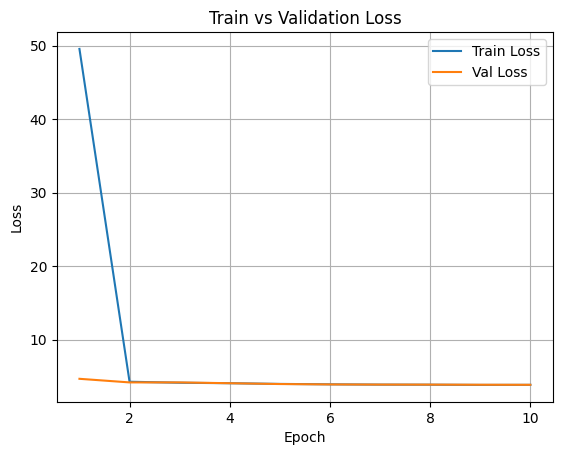

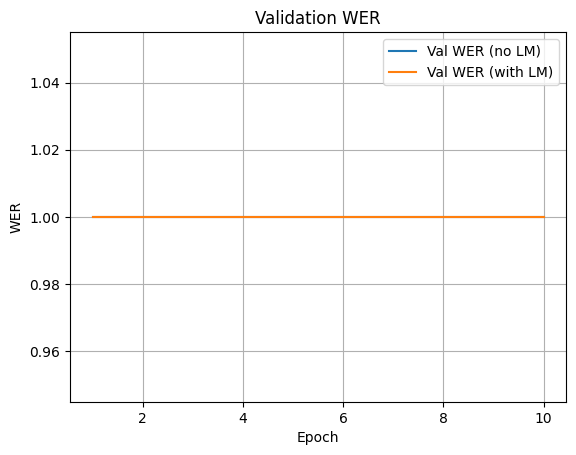

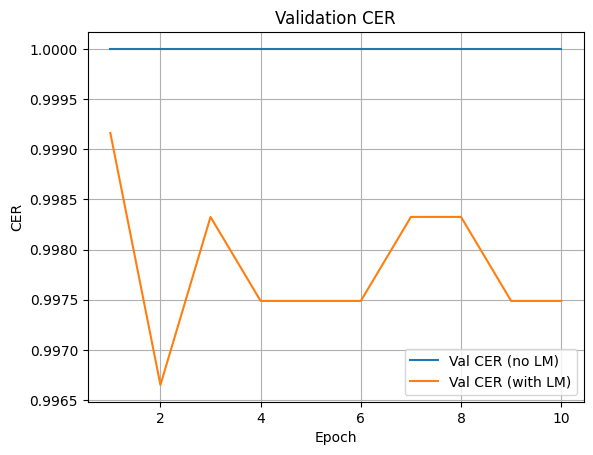

Levenshtein not found in history (skipping Levenshtein plot).

TEST METRICS
  Loss: 3.829710009110034
  no_lm   -> {'wer': 1.0, 'cer': 1.0, 'levenshtein': 4.798994974874372}
  with_lm -> {'wer': 0.9949748743718593, 'cer': 0.9941373534338358, 'levenshtein': 4.821608040201005}
Running for ratio : 0.7
Found 995 .pt files in /content/drive/MyDrive/EEG-to-Text/preprocessed_frames_flat
n_val : 348 | n_test : 348 |n_train : 299 
torch.Size([200, 127]) torch.float32 -2.0720224380493164 2.828300714492798

Epoch 1/10


Eval: 100%|██████████| 22/22 [00:15<00:00,  1.42it/s]


Train Loss: 36.1245 | Val Loss: 4.3877
  no_lm   -> WER: 1.0000 | CER: 1.0000
  with_lm -> WER: 0.9943 | CER: 0.9943
Saved new best model to: /content/drive/MyDrive/EEG-to-Text/runs/run_2/best_model.pth

Epoch 2/10


Eval: 100%|██████████| 22/22 [00:14<00:00,  1.53it/s]


Train Loss: 4.2499 | Val Loss: 4.2746
  no_lm   -> WER: 1.0000 | CER: 1.0000
  with_lm -> WER: 0.9943 | CER: 0.9943
Saved new best model to: /content/drive/MyDrive/EEG-to-Text/runs/run_2/best_model.pth

Epoch 3/10


...

Train Loss: 3.8107 | Val Loss: 3.8470
  no_lm   -> WER: 1.0000 | CER: 1.0000
  with_lm -> WER: 0.9943 | CER: 0.9943

Epoch 10/10


Eval: 100%|██████████| 22/22 [00:14<00:00,  1.50it/s]


Train Loss: 3.8007 | Val Loss: 3.8624
  no_lm   -> WER: 1.0000 | CER: 1.0000
  with_lm -> WER: 0.9943 | CER: 0.9943

Training log saved to: /content/drive/MyDrive/EEG-to-Text/runs/run_2/training_log.json

Loaded best model: /content/drive/MyDrive/EEG-to-Text/runs/run_2/best_model.pth


Eval: 100%|██████████| 22/22 [00:20<00:00,  1.07it/s]



TEST Loss: 3.8358
  no_lm   -> WER: 1.0000 | CER: 1.0000 | LEV: 4.9368
  with_lm -> WER: 1.0000 | CER: 1.0000 | LEV: 4.9339

Updated training log (with test results): /content/drive/MyDrive/EEG-to-Text/runs/run_2/training_log.json


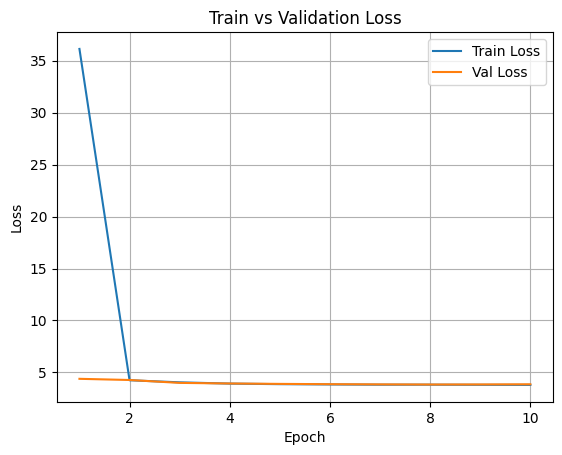

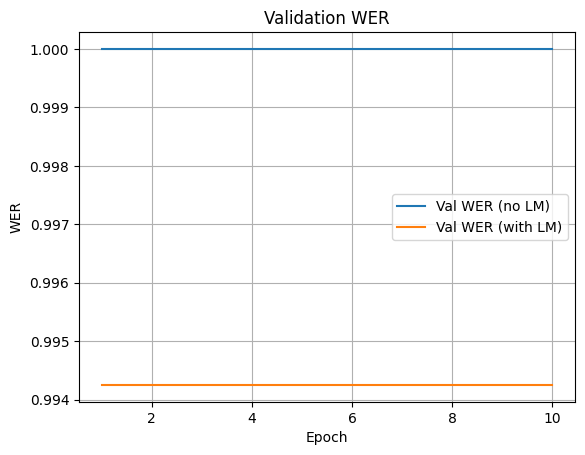

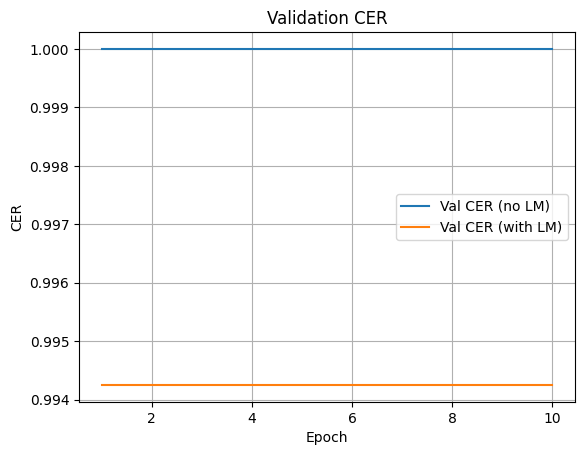

Levenshtein not found in history (skipping Levenshtein plot).

TEST METRICS
  Loss: 3.835807087777675
  no_lm   -> {'wer': 1.0, 'cer': 1.0, 'levenshtein': 4.936781609195402}
  with_lm -> {'wer': 1.0, 'cer': 1.0, 'levenshtein': 4.933908045977011}
Running for ratio : 0.6
Found 995 .pt files in /content/drive/MyDrive/EEG-to-Text/preprocessed_frames_flat
n_val : 298 | n_test : 298 |n_train : 399 
torch.Size([200, 127]) torch.float32 -2.0720224380493164 2.828300714492798

Epoch 1/10


Eval: 100%|██████████| 19/19 [00:14<00:00,  1.35it/s]


Train Loss: 52.2553 | Val Loss: 4.3305
  no_lm   -> WER: 0.9966 | CER: 0.9966
  with_lm -> WER: 0.9966 | CER: 0.9966
Saved new best model to: /content/drive/MyDrive/EEG-to-Text/runs/run_3/best_model.pth

Epoch 2/10


Eval: 100%|██████████| 19/19 [00:12<00:00,  1.49it/s]


Train Loss: 4.2268 | Val Loss: 4.1727
  no_lm   -> WER: 0.9966 | CER: 0.9966
  with_lm -> WER: 0.9966 | CER: 0.9966
Saved new best model to: /content/drive/MyDrive/EEG-to-Text/runs/run_3/best_model.pth

Epoch 3/10


...

Train Loss: 3.7898 | Val Loss: 3.8704
  no_lm   -> WER: 0.9966 | CER: 0.9966
  with_lm -> WER: 0.9966 | CER: 0.9966
Saved new best model to: /content/drive/MyDrive/EEG-to-Text/runs/run_3/best_model.pth

Epoch 10/10


Eval: 100%|██████████| 19/19 [00:12<00:00,  1.51it/s]


Train Loss: 3.7832 | Val Loss: 3.8712
  no_lm   -> WER: 0.9966 | CER: 0.9966
  with_lm -> WER: 0.9966 | CER: 0.9966

Training log saved to: /content/drive/MyDrive/EEG-to-Text/runs/run_3/training_log.json

Loaded best model: /content/drive/MyDrive/EEG-to-Text/runs/run_3/best_model.pth


Eval: 100%|██████████| 19/19 [00:12<00:00,  1.48it/s]



TEST Loss: 3.8056
  no_lm   -> WER: 0.9966 | CER: 0.9966 | LEV: 4.8557
  with_lm -> WER: 0.9966 | CER: 0.9966 | LEV: 4.8557

Updated training log (with test results): /content/drive/MyDrive/EEG-to-Text/runs/run_3/training_log.json


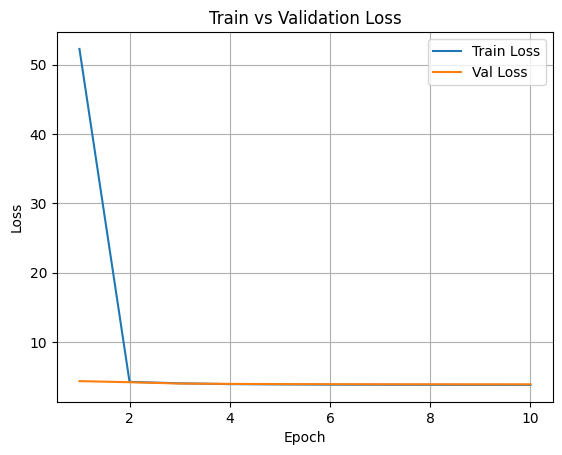

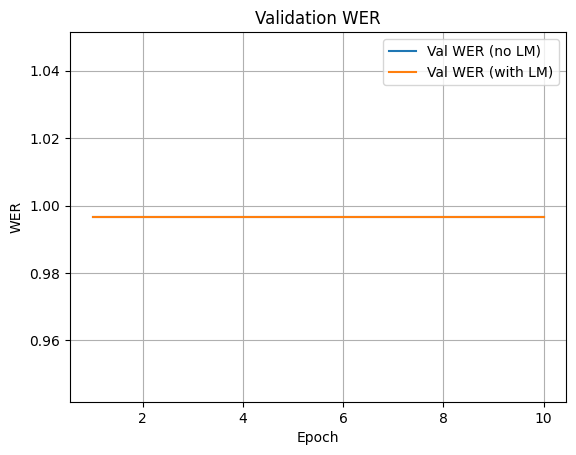

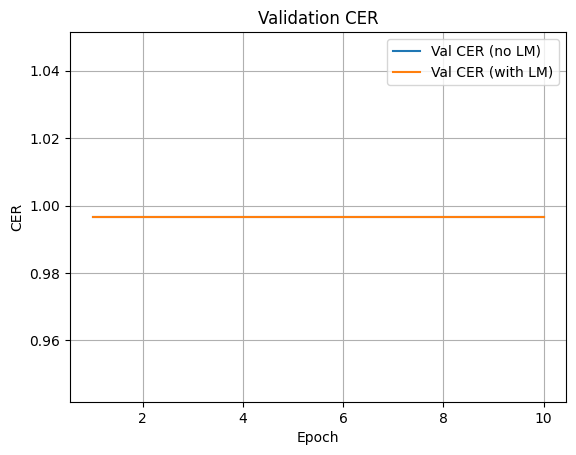

Levenshtein not found in history (skipping Levenshtein plot).

TEST METRICS
  Loss: 3.805585862806179
  no_lm   -> {'wer': 0.9966442953020134, 'cer': 0.9966442953020134, 'levenshtein': 4.855704697986577}
  with_lm -> {'wer': 0.9966442953020134, 'cer': 0.9966442953020134, 'levenshtein': 4.855704697986577}
Running for ratio : 0.5
Found 995 .pt files in /content/drive/MyDrive/EEG-to-Text/preprocessed_frames_flat
n_val : 249 | n_test : 249 |n_train : 497 
torch.Size([200, 127]) torch.float32 -2.0720224380493164 2.828300714492798

Epoch 1/10


Eval: 100%|██████████| 16/16 [00:13<00:00,  1.21it/s]


Train Loss: 22.2940 | Val Loss: 4.2962
  no_lm   -> WER: 0.9960 | CER: 0.9960
  with_lm -> WER: 0.9960 | CER: 0.9960
Saved new best model to: /content/drive/MyDrive/EEG-to-Text/runs/run_4/best_model.pth

Epoch 2/10


Eval: 100%|██████████| 16/16 [00:09<00:00,  1.71it/s]


Train Loss: 4.0415 | Val Loss: 3.9488
  no_lm   -> WER: 0.9960 | CER: 0.9960
  with_lm -> WER: 0.9960 | CER: 0.9960
Saved new best model to: /content/drive/MyDrive/EEG-to-Text/runs/run_4/best_model.pth

Epoch 3/10


...

Train Loss: 3.7786 | Val Loss: 3.8255
  no_lm   -> WER: 0.9960 | CER: 0.9960
  with_lm -> WER: 0.9960 | CER: 0.9960
Saved new best model to: /content/drive/MyDrive/EEG-to-Text/runs/run_4/best_model.pth

Epoch 10/10


Eval: 100%|██████████| 16/16 [00:11<00:00,  1.34it/s]


Train Loss: 3.7862 | Val Loss: 3.8492
  no_lm   -> WER: 0.9960 | CER: 0.9960
  with_lm -> WER: 0.9960 | CER: 0.9960

Training log saved to: /content/drive/MyDrive/EEG-to-Text/runs/run_4/training_log.json

Loaded best model: /content/drive/MyDrive/EEG-to-Text/runs/run_4/best_model.pth


Eval: 100%|██████████| 16/16 [00:13<00:00,  1.16it/s]



TEST Loss: 3.8369
  no_lm   -> WER: 0.9920 | CER: 0.9920 | LEV: 4.9518
  with_lm -> WER: 0.9880 | CER: 0.9880 | LEV: 4.9478

Updated training log (with test results): /content/drive/MyDrive/EEG-to-Text/runs/run_4/training_log.json


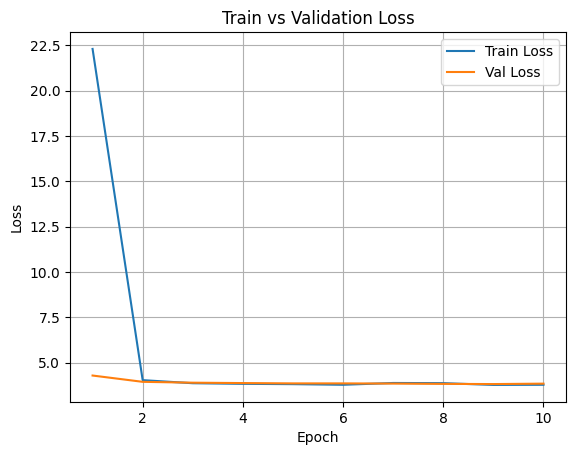

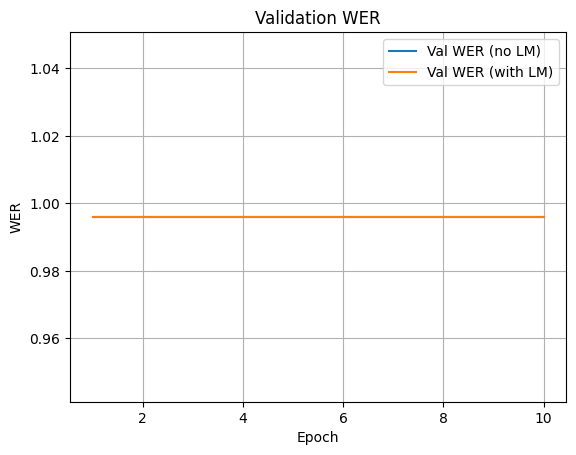

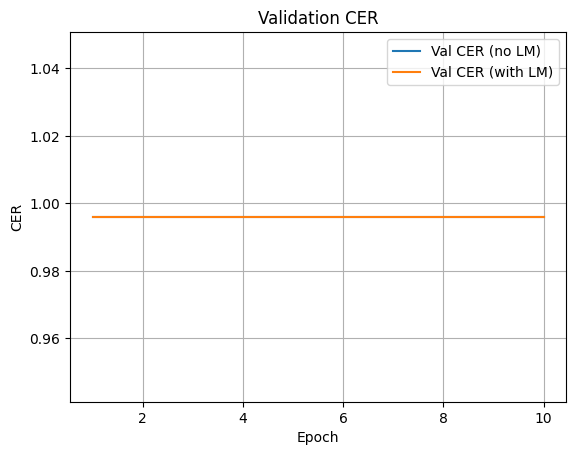

Levenshtein not found in history (skipping Levenshtein plot).

TEST METRICS
  Loss: 3.836881189461214
  no_lm   -> {'wer': 0.9919678714859438, 'cer': 0.9919678714859438, 'levenshtein': 4.951807228915663}
  with_lm -> {'wer': 0.9879518072289156, 'cer': 0.9879518072289156, 'levenshtein': 4.947791164658635}
Running for ratio : 0.4
Found 995 .pt files in /content/drive/MyDrive/EEG-to-Text/preprocessed_frames_flat
n_val : 199 | n_test : 199 |n_train : 597 
torch.Size([200, 127]) torch.float32 -2.0720224380493164 2.828300714492798

Epoch 1/10


Eval: 100%|██████████| 13/13 [00:09<00:00,  1.37it/s]


Train Loss: 26.5285 | Val Loss: 4.3093
  no_lm   -> WER: 1.0000 | CER: 1.0000
  with_lm -> WER: 0.9950 | CER: 0.9950
Saved new best model to: /content/drive/MyDrive/EEG-to-Text/runs/run_5/best_model.pth

Epoch 2/10


Eval: 100%|██████████| 13/13 [00:09<00:00,  1.37it/s]


Train Loss: 4.0489 | Val Loss: 3.9367
  no_lm   -> WER: 1.0000 | CER: 1.0000
  with_lm -> WER: 0.9950 | CER: 0.9950
Saved new best model to: /content/drive/MyDrive/EEG-to-Text/runs/run_5/best_model.pth

Epoch 3/10


...

Train Loss: 3.8038 | Val Loss: 3.8679
  no_lm   -> WER: 1.0000 | CER: 1.0000
  with_lm -> WER: 0.9950 | CER: 0.9950

Epoch 10/10


Eval: 100%|██████████| 13/13 [00:08<00:00,  1.55it/s]


Train Loss: 3.7888 | Val Loss: 3.8564
  no_lm   -> WER: 1.0000 | CER: 1.0000
  with_lm -> WER: 0.9950 | CER: 0.9950

Training log saved to: /content/drive/MyDrive/EEG-to-Text/runs/run_5/training_log.json

Loaded best model: /content/drive/MyDrive/EEG-to-Text/runs/run_5/best_model.pth


Eval: 100%|██████████| 13/13 [00:10<00:00,  1.25it/s]



TEST Loss: 3.7806
  no_lm   -> WER: 1.0000 | CER: 1.0000 | LEV: 4.8995
  with_lm -> WER: 0.9899 | CER: 0.9899 | LEV: 4.9296

Updated training log (with test results): /content/drive/MyDrive/EEG-to-Text/runs/run_5/training_log.json


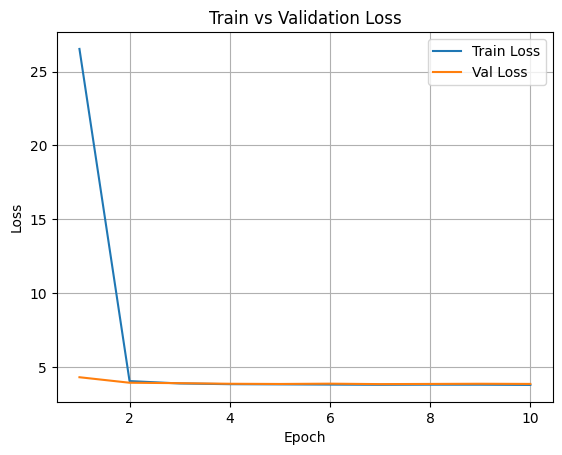

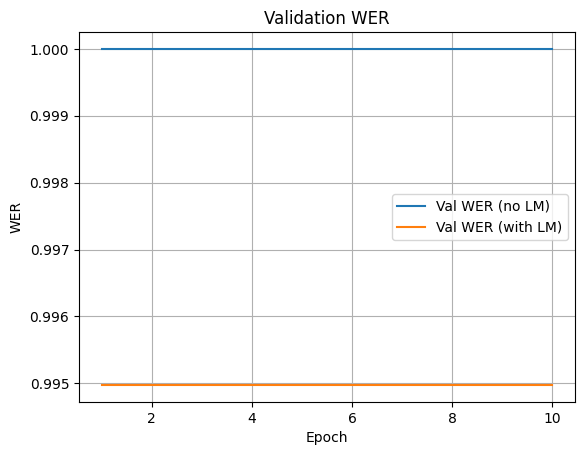

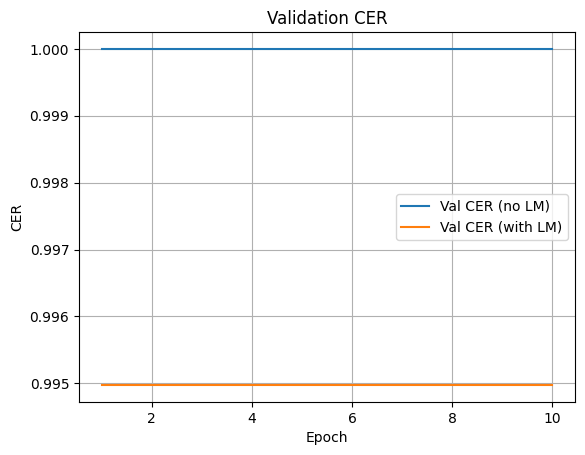

Levenshtein not found in history (skipping Levenshtein plot).

TEST METRICS
  Loss: 3.7805767514597832
  no_lm   -> {'wer': 1.0, 'cer': 1.0, 'levenshtein': 4.899497487437186}
  with_lm -> {'wer': 0.9899497487437185, 'cer': 0.9899497487437185, 'levenshtein': 4.9296482412060305}
Running for ratio : 0.3
Found 995 .pt files in /content/drive/MyDrive/EEG-to-Text/preprocessed_frames_flat
n_val : 149 | n_test : 149 |n_train : 697 
torch.Size([200, 127]) torch.float32 -2.0720224380493164 2.828300714492798

Epoch 1/10


Eval: 100%|██████████| 10/10 [00:07<00:00,  1.39it/s]


Train Loss: 29.2898 | Val Loss: 4.2913
  no_lm   -> WER: 1.0000 | CER: 1.0000
  with_lm -> WER: 1.0000 | CER: 1.0000
Saved new best model to: /content/drive/MyDrive/EEG-to-Text/runs/run_6/best_model.pth

Epoch 2/10


Eval: 100%|██████████| 10/10 [00:06<00:00,  1.45it/s]


Train Loss: 4.0518 | Val Loss: 3.9745
  no_lm   -> WER: 1.0000 | CER: 1.0000
  with_lm -> WER: 1.0000 | CER: 1.0000
Saved new best model to: /content/drive/MyDrive/EEG-to-Text/runs/run_6/best_model.pth

Epoch 3/10


...

Train Loss: 3.8070 | Val Loss: 3.8583
  no_lm   -> WER: 1.0000 | CER: 1.0000
  with_lm -> WER: 1.0000 | CER: 1.0000

Epoch 10/10


Eval: 100%|██████████| 10/10 [00:07<00:00,  1.33it/s]


Train Loss: 3.8045 | Val Loss: 3.8331
  no_lm   -> WER: 1.0000 | CER: 1.0000
  with_lm -> WER: 1.0000 | CER: 1.0000

Training log saved to: /content/drive/MyDrive/EEG-to-Text/runs/run_6/training_log.json

Loaded best model: /content/drive/MyDrive/EEG-to-Text/runs/run_6/best_model.pth


Eval: 100%|██████████| 10/10 [00:07<00:00,  1.40it/s]



TEST Loss: 3.7312
  no_lm   -> WER: 1.0000 | CER: 1.0000 | LEV: 4.8255
  with_lm -> WER: 0.9933 | CER: 0.9933 | LEV: 4.7987

Updated training log (with test results): /content/drive/MyDrive/EEG-to-Text/runs/run_6/training_log.json


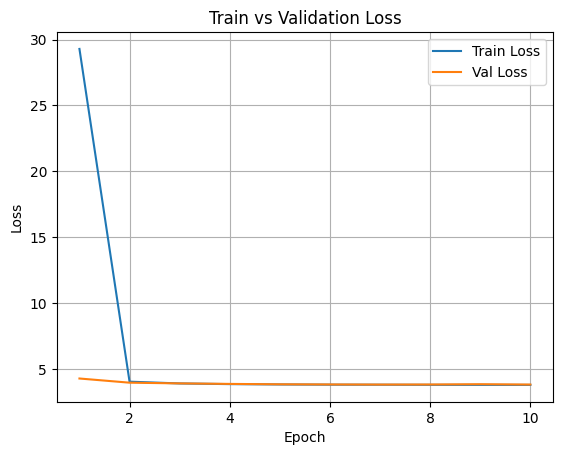

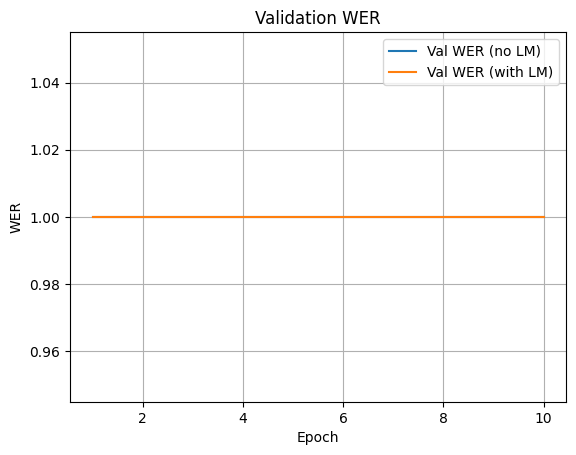

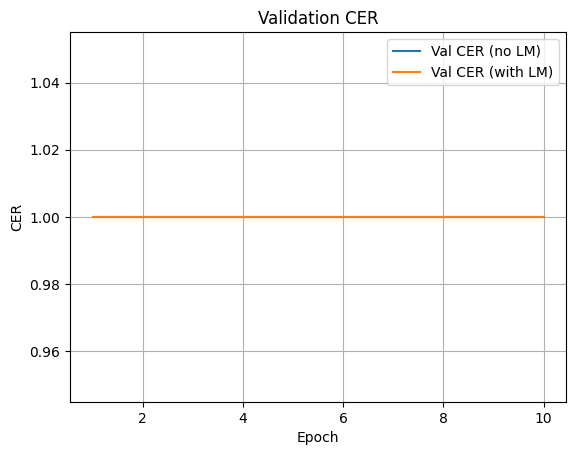

Levenshtein not found in history (skipping Levenshtein plot).

TEST METRICS
  Loss: 3.7312220359008585
  no_lm   -> {'wer': 1.0, 'cer': 1.0, 'levenshtein': 4.825503355704698}
  with_lm -> {'wer': 0.9932885906040269, 'cer': 0.9932885906040269, 'levenshtein': 4.798657718120805}
Running for ratio : 0.2
Found 995 .pt files in /content/drive/MyDrive/EEG-to-Text/preprocessed_frames_flat
n_val : 100 | n_test : 100 |n_train : 795 
torch.Size([200, 127]) torch.float32 -2.0720224380493164 2.828300714492798

Epoch 1/10


Eval: 100%|██████████| 7/7 [00:04<00:00,  1.60it/s]


Train Loss: 16.0049 | Val Loss: 4.1129
  no_lm   -> WER: 1.0000 | CER: 1.0000
  with_lm -> WER: 1.0000 | CER: 1.0000
Saved new best model to: /content/drive/MyDrive/EEG-to-Text/runs/run_7/best_model.pth

Epoch 2/10


Eval: 100%|██████████| 7/7 [00:04<00:00,  1.68it/s]


Train Loss: 3.9309 | Val Loss: 3.9293
  no_lm   -> WER: 1.0000 | CER: 1.0000
  with_lm -> WER: 1.0000 | CER: 1.0000
Saved new best model to: /content/drive/MyDrive/EEG-to-Text/runs/run_7/best_model.pth

Epoch 3/10


...

Train Loss: 3.7570 | Val Loss: 3.8547
  no_lm   -> WER: 1.0000 | CER: 1.0000
  with_lm -> WER: 1.0000 | CER: 1.0000

Epoch 10/10


Eval: 100%|██████████| 7/7 [00:04<00:00,  1.44it/s]


Train Loss: 3.7471 | Val Loss: 3.8408
  no_lm   -> WER: 1.0000 | CER: 1.0000
  with_lm -> WER: 1.0000 | CER: 1.0000
Saved new best model to: /content/drive/MyDrive/EEG-to-Text/runs/run_7/best_model.pth

Training log saved to: /content/drive/MyDrive/EEG-to-Text/runs/run_7/training_log.json

Loaded best model: /content/drive/MyDrive/EEG-to-Text/runs/run_7/best_model.pth


Eval: 100%|██████████| 7/7 [00:05<00:00,  1.35it/s]



TEST Loss: 3.9634
  no_lm   -> WER: 1.0000 | CER: 1.0000 | LEV: 4.4700
  with_lm -> WER: 1.0000 | CER: 1.0000 | LEV: 4.4700

Updated training log (with test results): /content/drive/MyDrive/EEG-to-Text/runs/run_7/training_log.json


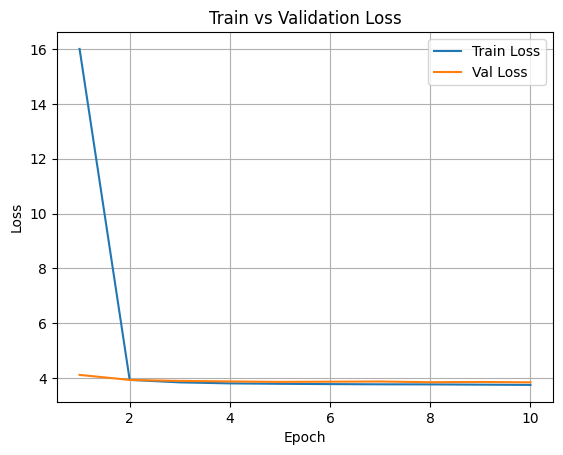

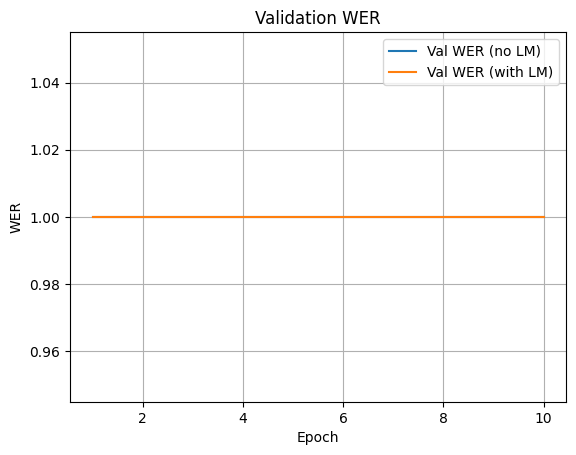

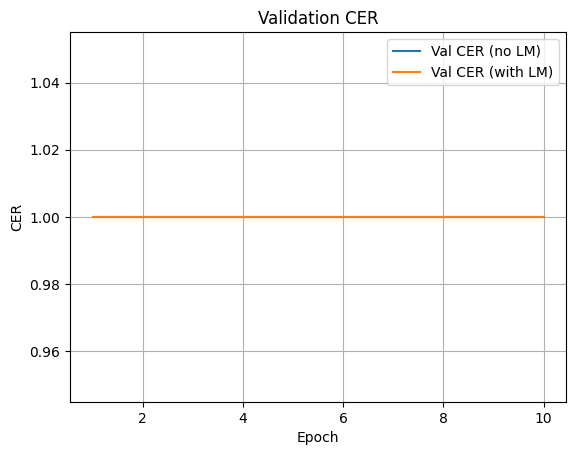

Levenshtein not found in history (skipping Levenshtein plot).

TEST METRICS
  Loss: 3.9634346961975098
  no_lm   -> {'wer': 1.0, 'cer': 1.0, 'levenshtein': 4.47}
  with_lm -> {'wer': 1.0, 'cer': 1.0, 'levenshtein': 4.47}


In [112]:
# ============================
# This cell:
# 1) builds dataset + loaders using get_data_set_and_loader
# 2) trains using train_model (which validates each epoch using compare_decoders)
# 3) loads the best checkpoint
# 4) tests by reusing compare_decoders(model, test_loader, ...)
# 5) appends test metrics into the SAME JSON log file

import os
import json
import torch

# ---- CONFIG ----
root_dir = "/content/drive/MyDrive/EEG-to-Text/preprocessed_frames_flat"
batch_size = 16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
run_id = 0
ratios = sorted([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8],reverse=True)
for ratio in ratios:
  run_id += 1
  run_dir = f"/content/drive/MyDrive/EEG-to-Text/runs/run_{run_id}"
  print(f"Running for ratio : {ratio}")
  run_log, train_loader, val_loader, test_loader, model,test_metrics = train_validate_test_visualise(root_dir, ratio, char_to_int, ctc_collate_fn, batch_size, run_dir=run_dir, epochs=10)

Running for ratio : 0.5
Found 995 .pt files in /content/drive/MyDrive/EEG-to-Text/preprocessed_frames_flat
n_val : 249 | n_test : 249 |n_train : 497 
torch.Size([100, 127]) torch.float32 -2.0720224380493164 2.6007208824157715

Epoch 1/20


Eval: 100%|██████████| 16/16 [00:14<00:00,  1.08it/s]


     ground_truth prediction_no_lm prediction_with_lm
0            door               ee                  e
1             mij              ees                een
2         kasteel               ee                  e
3          direct               ee                  e
4             uit              ees                een
..            ...              ...                ...
244       meisjes              ees                een
245          naar              ees                een
246      wegpakte              ees                een
247  onmiddellijk              ees                een
248          door               ee                  e

[249 rows x 3 columns]
Train Loss: 78.5137 | Val Loss: 5.6392
  no_lm   -> WER: 1.0000 | CER: 0.8712
  with_lm -> WER: 0.9960 | CER: 0.8763
Saved new best model to: /content/drive/MyDrive/EEG-to-Text/runs/run_1/best_model.pth

Epoch 2/20


Eval: 100%|██████████| 16/16 [00:10<00:00,  1.47it/s]


    ground_truth prediction_no_lm prediction_with_lm
0            kin                s                  1
1        kasteel                s                  1
2           zich                s                  1
3            met                                    
4       wegpakte                s                  1
..           ...              ...                ...
244      bevrijd                                    
245          van                s                  1
246          het                                    
247           of                s                  1
248        groen                s                  1

[249 rows x 3 columns]
Train Loss: 9.3681 | Val Loss: 8.6928
  no_lm   -> WER: 1.0000 | CER: 1.0000
  with_lm -> WER: 0.9960 | CER: 0.9960

Epoch 3/20


...

      ground_truth prediction_no_lm prediction_with_lm
0    teruggekregen    eaeaeaeaeaeai             eaters
1         wegpakte    eaeaeaeaeaeai             eaters
2              nog    eaeaeaeaeaeai             eaters
3          bevrijd     eaeaeaeaeaea             eaters
4                6    eaeaeaeaeaeai             eaters
..             ...              ...                ...
244  teruggekregen                s                  1
245             10    eaeaeaeaeaeai             eaters
246      bloedrode     eaeaeaeaeaea             eaters
247        donkere     eaeaeaeaeaea             eaters
248            hun     eaeaeaeaeaea             eaters

[249 rows x 3 columns]
Train Loss: 3.8439 | Val Loss: 8.4151
  no_lm   -> WER: 1.0000 | CER: 0.8566
  with_lm -> WER: 1.0000 | CER: 0.7997

Epoch 20/20


Eval: 100%|██████████| 16/16 [00:48<00:00,  3.01s/it]


      ground_truth prediction_no_lm prediction_with_lm
0     binnenplaats    eaeaeaeaeaeas             eating
1            waren                s                  1
2     onmiddellijk                s                  1
3              sok    eaeaeaeaeaeas             eating
4              bak                s                  1
..             ...              ...                ...
244        braadde                s                  1
245       wegpakte                s                  1
246        verlost    eaeaeaeaeaeas             eating
247            kin                s                  1
248  teruggekregen                s                  1

[249 rows x 3 columns]
Train Loss: 3.8258 | Val Loss: 8.5185
  no_lm   -> WER: 1.0000 | CER: 0.9382
  with_lm -> WER: 0.9960 | CER: 0.9189

Training log saved to: /content/drive/MyDrive/EEG-to-Text/runs/run_1/training_log.json

Loaded best model: /content/drive/MyDrive/EEG-to-Text/runs/run_1/best_model.pth


Eval: 100%|██████████| 16/16 [00:17<00:00,  1.07s/it]


    ground_truth prediction_no_lm prediction_with_lm
0             nu               ee                  e
1            dan              ees                een
2              7               ee                  e
3       vogeltje              ees                een
4         direct              ees                een
..           ...              ...                ...
244        mooie              ees                een
245            5               ee                  e
246      vlakbij              ees                een
247           12              ees                een
248          ook              ees                een

[249 rows x 3 columns]

TEST Loss: 5.7155
  no_lm   -> WER: 1.0000 | CER: 0.8683 | LEV: 4.4056
  with_lm -> WER: 0.9920 | CER: 0.8795 | LEV: 4.3052

Updated training log (with test results): /content/drive/MyDrive/EEG-to-Text/runs/run_1/training_log.json


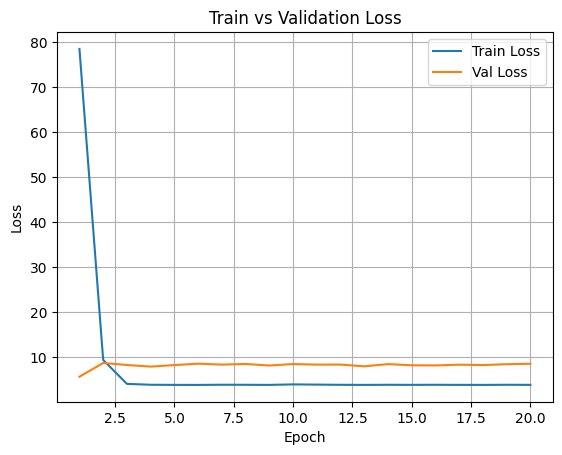

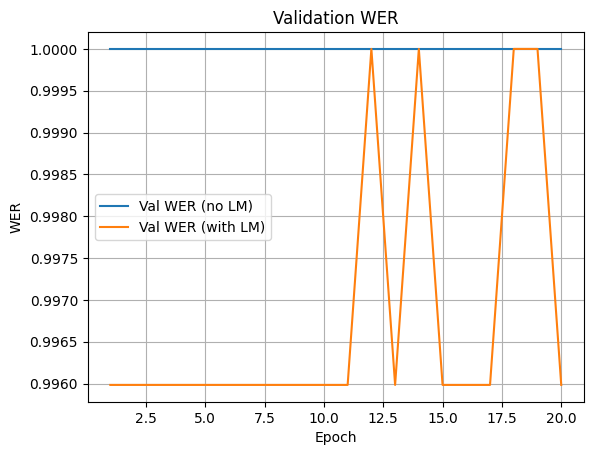

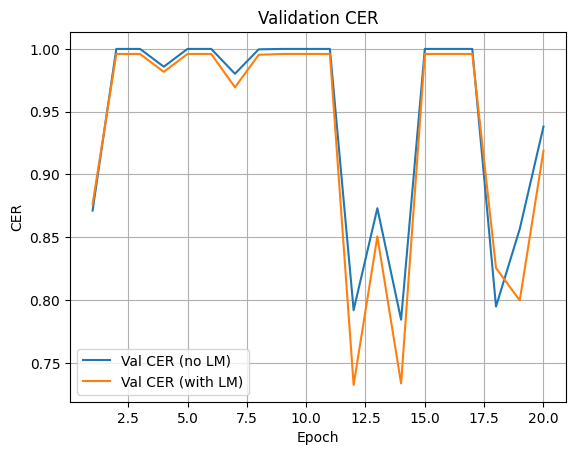

Levenshtein not found in history (skipping Levenshtein plot).

TEST METRICS
  Loss: 5.715482144949426
  no_lm   -> {'wer': 1.0, 'cer': 0.8682730923694774, 'levenshtein': 4.405622489959839}
  with_lm -> {'wer': 0.9919678714859438, 'cer': 0.8795180722891562, 'levenshtein': 4.305220883534137}
Running for ratio : 0.4
Found 995 .pt files in /content/drive/MyDrive/EEG-to-Text/preprocessed_frames_flat
n_val : 199 | n_test : 199 |n_train : 597 
torch.Size([100, 127]) torch.float32 -2.0720224380493164 2.6007208824157715

Epoch 1/20


Eval: 100%|██████████| 13/13 [00:34<00:00,  2.63s/it]


    ground_truth prediction_no_lm prediction_with_lm
0            hun     aeaaaaeaaaaa              aaaaa
1           werd     aeaaaaeaaaaa              aaaaa
2    dauwdruppel     aeaaaaeaaaaa              aaaaa
3            dan     aeaaaaeaaaaa              aaaaa
4           voor    aeaaeaaaeaaaa              aaaaa
..           ...              ...                ...
194         maar     aeaaaaeaaaaa              aaaaa
195       struik     aeaaaaeaaaaa              aaaaa
196       struik     aeaaaaeaaaaa              aaaaa
197           nu     aeaaaaeaaaaa              aaaaa
198      kasteel     aeaaaaeaaaaa              aaaaa

[199 rows x 3 columns]
Train Loss: 80.5692 | Val Loss: 13.6231
  no_lm   -> WER: 1.0000 | CER: 0.7963
  with_lm -> WER: 1.0000 | CER: 0.8096
Saved new best model to: /content/drive/MyDrive/EEG-to-Text/runs/run_2/best_model.pth

Epoch 2/20


Eval: 100%|██████████| 13/13 [00:06<00:00,  2.17it/s]


     ground_truth prediction_no_lm prediction_with_lm
0         wanneer                                   2
1              nu                                   2
2             dan                                    
3             had                                    
4           juist                                    
..            ...              ...                ...
194             9                                    
195           kin                                   2
196  zevenduizend                                   2
197   dauwdruppel                                   2
198           vak                                   2

[199 rows x 3 columns]
Train Loss: 19.0289 | Val Loss: 8.7600
  no_lm   -> WER: 1.0000 | CER: 1.0000
  with_lm -> WER: 1.0000 | CER: 1.0000
Saved new best model to: /content/drive/MyDrive/EEG-to-Text/runs/run_2/best_model.pth

Epoch 3/20


...

     ground_truth prediction_no_lm prediction_with_lm
0     dauwdruppel                                   2
1          hierop                                   2
2             hem                                   2
3             vak                                   2
4           mooie                                   2
..            ...              ...                ...
194      zonlicht                                    
195           kin                                    
196          mooi                                    
197       braadde                                    
198  onmiddellijk                                   2

[199 rows x 3 columns]
Train Loss: 3.8522 | Val Loss: 8.1990
  no_lm   -> WER: 1.0000 | CER: 1.0000
  with_lm -> WER: 1.0000 | CER: 1.0000

Epoch 20/20


Eval: 100%|██████████| 13/13 [00:06<00:00,  2.10it/s]


    ground_truth prediction_no_lm prediction_with_lm
0           mijn                                    
1             om                                   2
2            uit                                    
3            dan                                    
4         daarna                                   2
..           ...              ...                ...
194          hoe                                    
195            8                                    
196           je                                    
197          zei                                    
198       struik                                    

[199 rows x 3 columns]
Train Loss: 3.8297 | Val Loss: 8.3771
  no_lm   -> WER: 1.0000 | CER: 1.0000
  with_lm -> WER: 1.0000 | CER: 1.0000

Training log saved to: /content/drive/MyDrive/EEG-to-Text/runs/run_2/training_log.json

Loaded best model: /content/drive/MyDrive/EEG-to-Text/runs/run_2/best_model.pth


Eval: 100%|██████████| 13/13 [01:11<00:00,  5.51s/it]


     ground_truth prediction_no_lm prediction_with_lm
0    zevenduizend    eaeneaeaeneao             eaters
1          bakker                                   2
2              te                                   2
3             bak    eaeneaeaeneno             eaters
4              al    eaeneaeaeneao             eaters
..            ...              ...                ...
194   redetwisten                                   2
195       gefluit    eaeneaeneneao             eaters
196           uit                                    
197           hoe                                    
198        totdat    eaeneaeneneao             eaters

[199 rows x 3 columns]

TEST Loss: 8.0909
  no_lm   -> WER: 1.0000 | CER: 0.8350 | LEV: 9.6030
  with_lm -> WER: 1.0000 | CER: 0.7910 | LEV: 5.6030

Updated training log (with test results): /content/drive/MyDrive/EEG-to-Text/runs/run_2/training_log.json


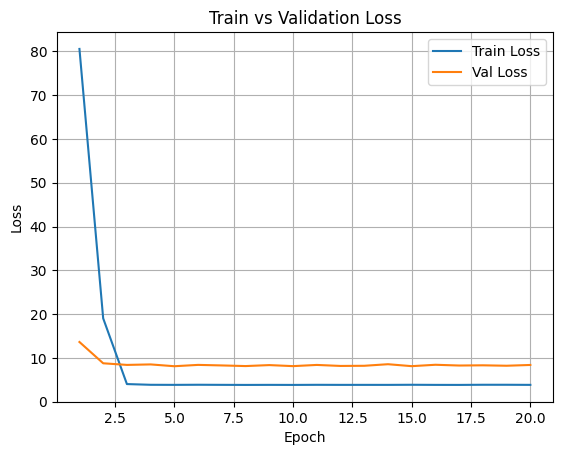

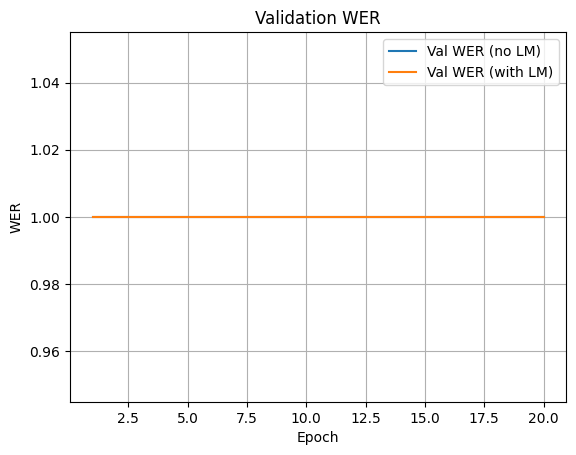

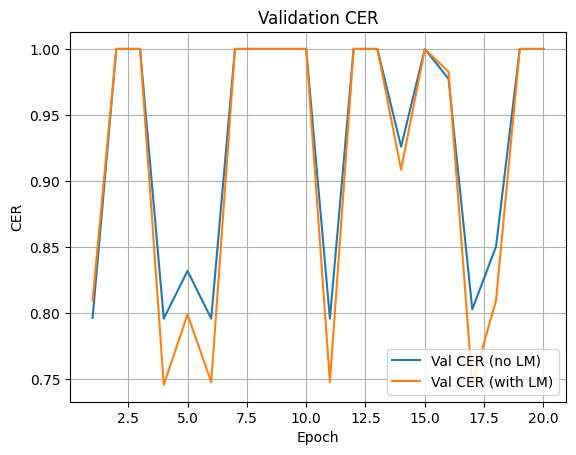

Levenshtein not found in history (skipping Levenshtein plot).

TEST METRICS
  Loss: 8.090867929123155
  no_lm   -> {'wer': 1.0, 'cer': 0.8349573956740217, 'levenshtein': 9.603015075376884}
  with_lm -> {'wer': 1.0, 'cer': 0.7909547738693467, 'levenshtein': 5.603015075376884}


In [178]:
root_dir = "/content/drive/MyDrive/EEG-to-Text/preprocessed_frames_flat"
batch_size = 16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
run_id = 0
ratios = sorted([ 0.4, 0.5],reverse=True)
for ratio in ratios:
  run_id += 1
  run_dir = f"/content/drive/MyDrive/EEG-to-Text/runs/run_{run_id}"
  print(f"Running for ratio : {ratio}")
  run_log, train_loader, val_loader, test_loader, model , test_metrics= train_validate_test_visualise(root_dir, ratio, char_to_int, ctc_collate_fn, batch_size, run_dir=run_dir, epochs=20)

Running for ratio : 0.8
Found 995 .pt files in /content/drive/MyDrive/EEG-to-Text/preprocessed_frames_flat
n_val : 398 | n_test : 398 |n_train : 199 
torch.Size([100, 127]) torch.float32 -2.0720224380493164 2.6007208824157715

Epoch 1/20


Eval: 100%|██████████| 20/20 [01:18<00:00,  3.91s/it]


    ground_truth        prediction_no_lm prediction_with_lm
0             je  eoeoeoeoeoeoeoeoeoeoeo               eien
1          buurt   eoeoeoeoeoeoeoeoeoeoe                  e
2        donkere  eoeoeoeoeoeoeoeoeoeoeo               eien
3            kin   eoeoeoeoeoeoeoeoeoeoe                  e
4            die   eoeoeoeoeoeoeoeoeoeoe                  e
..           ...                     ...                ...
393          kin   eoeoeoeoeoeoeoeoeoeoe               eien
394          mij   eoeoeoeoeoeoeoeoeoeoe                  e
395          wat   eoeoeoeoeoeoeoeoeoeoe                  e
396     wegpakte  eoeoeoeoeoeoeoeoeoeoeo               eien
397   verstijfde   eoeoeoeoeoeoeoeoeoeoe                  e

[398 rows x 3 columns]
Train Loss: 71.6848 | Val Loss: 68.8276
  no_lm   -> WER: 1.0000 | CER: 0.8820
  with_lm -> WER: 1.0000 | CER: 0.8622
Saved new best model to: /content/drive/MyDrive/EEG-to-Text/runs/run_3/best_model.pth

Epoch 2/20


Eval: 100%|██████████| 20/20 [01:06<00:00,  3.30s/it]


    ground_truth                               prediction_no_lm  \
0            dit   eaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaea   
1            wel   eaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaea   
2    noordenwind  eaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeae   
3     verstijfde   eaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaea   
4        smeekte  eaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeae   
..           ...                                            ...   
393        groen  eaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeae   
394      braadde   eaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaea   
395         voor  eaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeae   
396          van  eaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeae   
397           al   eaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaeaea   

    prediction_with_lm  
0                 eeae  
1                 eeae  
2                 eeae  
3                 eeae  
4                 eeae  
..                 ...  
393               ee

...

    ground_truth prediction_no_lm prediction_with_lm
0         bakker                                   2
1           veel                                   2
2            als                                    
3             nu                                   2
4             ze                                   2
..           ...              ...                ...
393         mooi                                    
394          ook                                   2
395        mooie                                   2
396          zei                                   2
397          tak                                   2

[398 rows x 3 columns]
Train Loss: 3.6239 | Val Loss: 8.4647
  no_lm   -> WER: 1.0000 | CER: 1.0000
  with_lm -> WER: 0.9925 | CER: 0.9925

Epoch 20/20


Eval: 100%|██████████| 20/20 [00:08<00:00,  2.29it/s]


    ground_truth prediction_no_lm prediction_with_lm
0            vak                                   2
1           niet                                   2
2            sok                                    
3            lij                                   2
4           haar                                   2
..           ...              ...                ...
393          tot                                   2
394           zo                                    
395    bloedrode                                   2
396          had                                   2
397          hoe                                   2

[398 rows x 3 columns]
Train Loss: 3.6347 | Val Loss: 8.1108
  no_lm   -> WER: 1.0000 | CER: 1.0000
  with_lm -> WER: 0.9925 | CER: 0.9925

Training log saved to: /content/drive/MyDrive/EEG-to-Text/runs/run_3/training_log.json

Loaded best model: /content/drive/MyDrive/EEG-to-Text/runs/run_3/best_model.pth


Eval: 100%|██████████| 20/20 [00:20<00:00,  1.04s/it]


     ground_truth prediction_no_lm      prediction_with_lm
0    binnenplaats                                        2
1             vak                                        2
2            naar    eneneneneneno             energetisch
3          spreuk                                        2
4              al                                        2
..            ...              ...                     ...
393         mooie                                        2
394       verlost                                        2
395       bevrijd    eneneneneneno  energontolerantiemeter
396            op                                         
397       gefluit                                         

[398 rows x 3 columns]

TEST Loss: 8.1106
  no_lm   -> WER: 1.0000 | CER: 0.9917 | LEV: 5.0905
  with_lm -> WER: 0.9950 | CER: 0.9865 | LEV: 5.1281

Updated training log (with test results): /content/drive/MyDrive/EEG-to-Text/runs/run_3/training_log.json


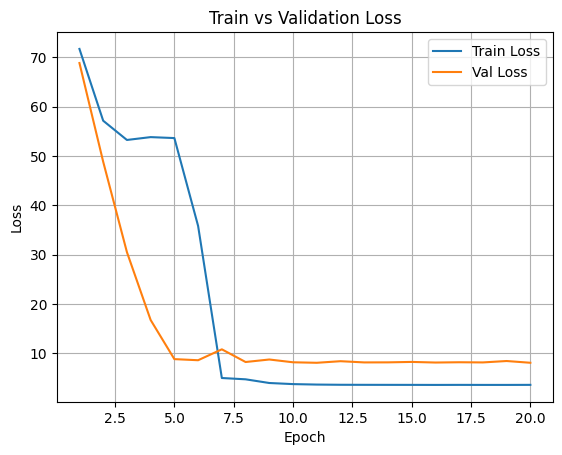

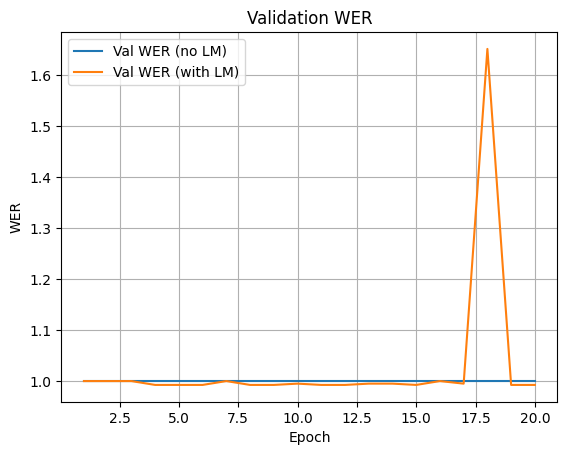

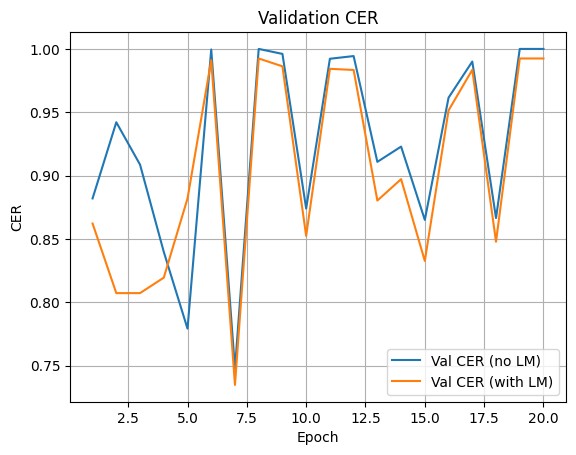

Levenshtein not found in history (skipping Levenshtein plot).

TEST METRICS
  Loss: 8.110586693538494
  no_lm   -> {'wer': 1.0, 'cer': 0.9916714004806643, 'levenshtein': 5.090452261306533}
  with_lm -> {'wer': 0.9949748743718593, 'cer': 0.9865189736055693, 'levenshtein': 5.128140703517588}
Running for ratio : 0.7
Found 995 .pt files in /content/drive/MyDrive/EEG-to-Text/preprocessed_frames_flat
n_val : 348 | n_test : 348 |n_train : 299 
torch.Size([100, 127]) torch.float32 -2.0720224380493164 2.6007208824157715

Epoch 1/20


Eval: 100%|██████████| 18/18 [01:24<00:00,  4.67s/it]


      ground_truth                               prediction_no_lm  \
0               er  oaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoao   
1             zich  oaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoao   
2               er  oaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoao   
3               in  oaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoao   
4    teruggekregen  oaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoao   
..             ...                                            ...   
343    redetwisten  oaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoao   
344        maantje  oaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoao   
345            het  oaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoao   
346     verstijfde  oaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoao   
347            hoe  oaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoaoao   

    prediction_with_lm  
0                    o  
1                  ono  
2                  ono  
3                    o  
4                  ono  
..                 ..

Eval: 100%|██████████| 18/18 [00:57<00:00,  3.20s/it]


    ground_truth          prediction_no_lm prediction_with_lm
0      bloedrode   eeeeeeeeeeeeeeeeeeeeeee              eenen
1        gefluit  eeeeeeeeeeeeeeeeeeeeeeea              eenen
2             de   eeeeeeeeeeeeeeeeeeeeeee              eenen
3     betovering   eeeeeeeeeeeeeeeeeeeeeee              eenen
4            hem  eeeeeeeeeeeeeeeeeeeeeeea              eenen
..           ...                       ...                ...
343       tussen   eeeeeeeeeeeeeeeeeeeeeee              eenen
344      kasteel   eeeeeeeeeeeeeeeeeeeeeee              eenen
345         voor   eeeeeeeeeeeeeeeeeeeeeee              eenen
346         door   eeeeeeeeeeeeeeeeeeeeeee              eenen
347   betovering   eeeeeeeeeeeeeeeeeeeeeee              eenen

[348 rows x 3 columns]
Train Loss: 75.9280 | Val Loss: 25.8018
  no_lm   -> WER: 1.0000 | CER: 0.8987
  with_lm -> WER: 1.0000 | CER: 0.7679
Saved new best model to: /content/drive/MyDrive/EEG-to-Text/runs/run_4/best_model.pth

Epoch 3/20


...

    ground_truth prediction_no_lm prediction_with_lm
0            lij    eaeaeaeaeaeat             eaters
1             in                                   1
2        braadde                                   1
3         dakker                                   1
4            ook                                   1
..           ...              ...                ...
343         door                                    
344            2                                   1
345       struik                                   1
346           er                                   1
347    verdwaald                                    

[348 rows x 3 columns]
Train Loss: 3.7577 | Val Loss: 8.0856
  no_lm   -> WER: 1.0000 | CER: 0.9679
  with_lm -> WER: 0.9943 | CER: 0.9446

Epoch 20/20


Eval: 100%|██████████| 18/18 [00:09<00:00,  1.88it/s]


     ground_truth prediction_no_lm prediction_with_lm
0    zevenduizend                                   1
1        vogeltje                                    
2          sprong                                   1
3               1                                    
4         bevrijd                                   1
..            ...              ...                ...
343            zo                                   1
344          zich                                    
345           zou                                   1
346         waren                                    
347            `s                                    

[348 rows x 3 columns]
Train Loss: 3.7617 | Val Loss: 8.0199
  no_lm   -> WER: 1.0000 | CER: 1.0000
  with_lm -> WER: 0.9914 | CER: 0.9914

Training log saved to: /content/drive/MyDrive/EEG-to-Text/runs/run_4/training_log.json

Loaded best model: /content/drive/MyDrive/EEG-to-Text/runs/run_4/best_model.pth


Eval: 100%|██████████| 18/18 [00:39<00:00,  2.19s/it]


    ground_truth prediction_no_lm prediction_with_lm
0         direct            eeeee                  e
1         tussen            eeeee                  e
2             de            eeeee                  e
3            tot           eeeeea                een
4             ze           eeeeea                een
..           ...              ...                ...
343        vloog           eeeeea                een
344       hierop            eeeee                  e
345          bij            eeeee                  e
346          hem           eeeeea                een
347      zanddak            eeeee                  e

[348 rows x 3 columns]

TEST Loss: 7.4648
  no_lm   -> WER: 1.0000 | CER: 0.7848 | LEV: 5.9138
  with_lm -> WER: 0.9971 | CER: 0.8897 | LEV: 4.3420

Updated training log (with test results): /content/drive/MyDrive/EEG-to-Text/runs/run_4/training_log.json


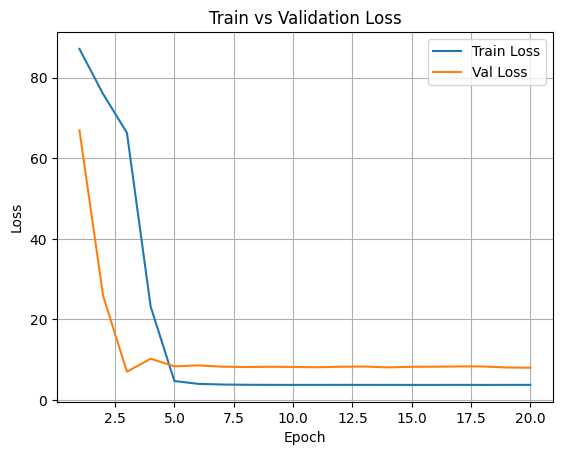

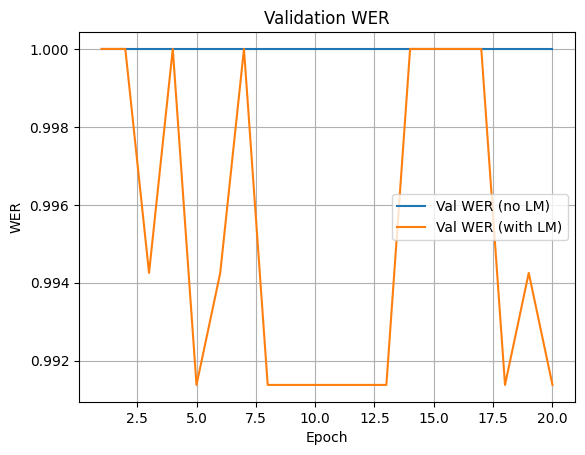

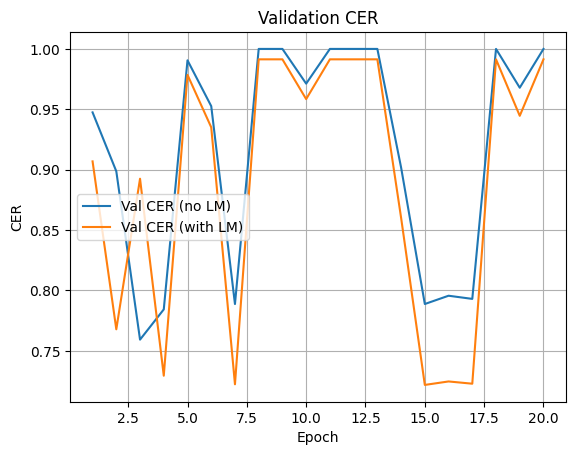

Levenshtein not found in history (skipping Levenshtein plot).

TEST METRICS
  Loss: 7.464797759878224
  no_lm   -> {'wer': 1.0, 'cer': 0.7848020434227312, 'levenshtein': 5.913793103448276}
  with_lm -> {'wer': 0.9971264367816092, 'cer': 0.8896551724137935, 'levenshtein': 4.341954022988506}
Running for ratio : 0.6
Found 995 .pt files in /content/drive/MyDrive/EEG-to-Text/preprocessed_frames_flat
n_val : 298 | n_test : 298 |n_train : 399 
torch.Size([100, 127]) torch.float32 -2.0720224380493164 2.6007208824157715

Epoch 1/20


Eval: 100%|██████████| 15/15 [01:08<00:00,  4.58s/it]


    ground_truth                               prediction_no_lm  \
0         schold  eoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoe   
1             ze  eoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoe   
2            kin  eoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoe   
3        vlakbij  eoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoe   
4             op  eoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoe   
..           ...                                            ...   
293          wak  eoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoe   
294            1  eoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoe   
295     sterkste  eoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoe   
296           de  eoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoe   
297          dan  eoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoeoe   

    prediction_with_lm  
0                eenen  
1                eenen  
2                eenen  
3                eenen  
4                eenen  
..                 ...  
293              een

Eval: 100%|██████████| 15/15 [00:27<00:00,  1.82s/it]


     ground_truth prediction_no_lm prediction_with_lm
0              11              nno                nel
1          sprong              nno                nel
2             dan               nn                 on
3    vogelkooitje              nno                nel
4             wak               nn                 on
..            ...              ...                ...
293         mooie              nno                nel
294            10              nno                nel
295            al              nno                nel
296       stiekem              nno                nel
297            al               nn                 on

[298 rows x 3 columns]
Train Loss: 73.0620 | Val Loss: 5.9844
  no_lm   -> WER: 1.0000 | CER: 0.8886
  with_lm -> WER: 1.0000 | CER: 0.8678
Saved new best model to: /content/drive/MyDrive/EEG-to-Text/runs/run_5/best_model.pth

Epoch 3/20


...

    ground_truth prediction_no_lm prediction_with_lm
0        donkere    eaoeaeaeaeaeo             eaters
1            hij     eaoeaeaeaeae             eaters
2             10    eaoeaeaeaeaeo             eaters
3      doodsbang    eaoeaeaeaeaeo             eaters
4             12     eaoeaeaeaeae             eaters
..           ...              ...                ...
293        mooie    eaoeaeaeaeaeo             eaters
294            3     eaoeaeaeaeae             eaters
295         zijn    eaoeaeaeaeaeo             eaters
296      wanneer    eaoeaeaeaeaeo             eaters
297      donkere    eaoeaeaeaeaeo             eaters

[298 rows x 3 columns]
Train Loss: 3.8076 | Val Loss: 8.4129
  no_lm   -> WER: 1.0000 | CER: 0.8567
  with_lm -> WER: 1.0000 | CER: 0.8051

Epoch 20/20


Eval: 100%|██████████| 15/15 [00:06<00:00,  2.15it/s]


     ground_truth prediction_no_lm prediction_with_lm
0              12                                    
1           helft                f                  s
2           vloog                f                  s
3             nog                f                  s
4     nachtegalen                f                  s
..            ...              ...                ...
293            op                f                  s
294       donkere                f                  s
295           die                                    
296  binnenplaats                f                  s
297            zo                                    

[298 rows x 3 columns]
Train Loss: 3.8141 | Val Loss: 8.4431
  no_lm   -> WER: 1.0000 | CER: 1.0000
  with_lm -> WER: 1.0000 | CER: 1.0000

Training log saved to: /content/drive/MyDrive/EEG-to-Text/runs/run_5/training_log.json

Loaded best model: /content/drive/MyDrive/EEG-to-Text/runs/run_5/best_model.pth


Eval: 100%|██████████| 15/15 [00:29<00:00,  1.96s/it]


     ground_truth prediction_no_lm prediction_with_lm
0               9              nno                nel
1              de               nn                 on
2    zevenduizend              nno                nel
3               8              nno                nel
4         maantje              nno                nel
..            ...              ...                ...
293           was               nn                 on
294    onschuldig              nno                nel
295           mij               nn                 on
296           wat              nno                nel
297       vlakbij              nno                nel

[298 rows x 3 columns]

TEST Loss: 5.8376
  no_lm   -> WER: 1.0000 | CER: 0.8919 | LEV: 4.7685
  with_lm -> WER: 1.0000 | CER: 0.8698 | LEV: 4.4195

Updated training log (with test results): /content/drive/MyDrive/EEG-to-Text/runs/run_5/training_log.json


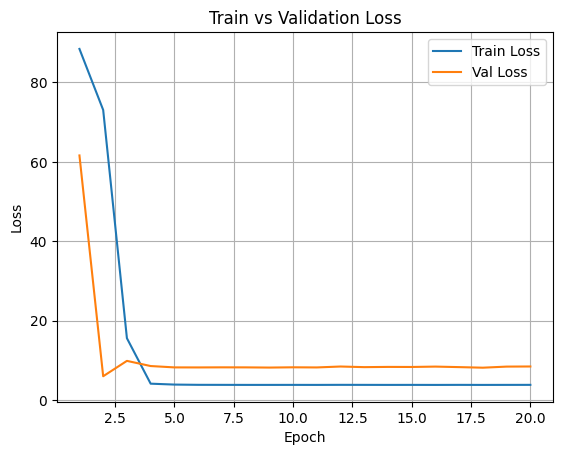

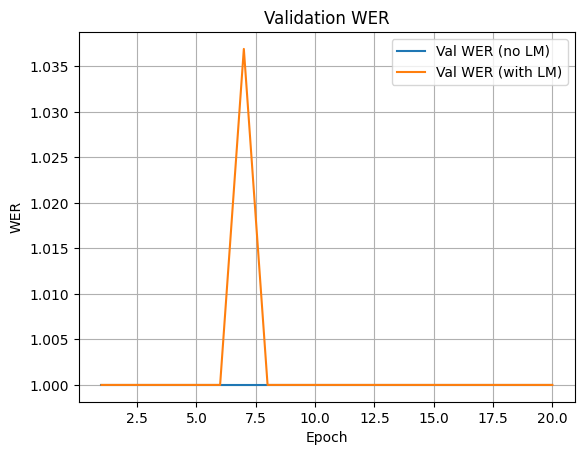

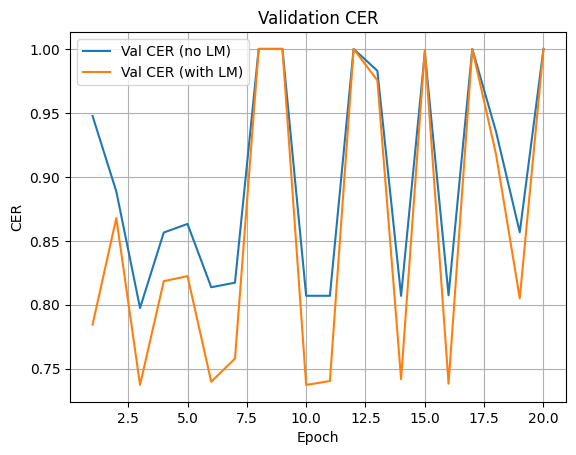

Levenshtein not found in history (skipping Levenshtein plot).

TEST METRICS
  Loss: 5.837580776854649
  no_lm   -> {'wer': 1.0, 'cer': 0.8919463087248318, 'levenshtein': 4.768456375838926}
  with_lm -> {'wer': 1.0, 'cer': 0.8697986577181206, 'levenshtein': 4.419463087248322}


In [179]:
batch_size = 20
ratios = sorted([ 0.6, 0.7, 0.8],reverse=True)
for ratio in ratios:
  run_id += 1
  run_dir = f"/content/drive/MyDrive/EEG-to-Text/runs/run_{run_id}"
  print(f"Running for ratio : {ratio}")
  run_log, train_loader, val_loader, test_loader, model ,test_metrics= train_validate_test_visualise(root_dir, ratio, char_to_int, ctc_collate_fn, batch_size, run_dir=run_dir, epochs=20)

In [ ]:
root_dir = "/content/drive/MyDrive/EEG-to-Text/preprocessed_frames_flat"
batch_size = 16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
run_id = 10
ratio = 0.4
df= pd.DataFrame()
for epochs in [14, 17]:
  run_id += 1
  run_dir = f"/content/drive/MyDrive/EEG-to-Text/runs/run_{run_id}"
  print(f"Running for ratio : {ratio}")
  run_log, train_loader, val_loader, test_loader, model, test_metrics= train_validate_test_visualise(root_dir, ratio, char_to_int, ctc_collate_fn, batch_size, run_dir=run_dir, epochs=epochs)
  df= create_df(test_metrics["predicted_words"])
  df.to_csv(f"/content/drive/MyDrive/EEG-to-Text/df_run_{run_id}.csv", index=False)

Running for ratio : 0.4
Found 995 .pt files in /content/drive/MyDrive/EEG-to-Text/preprocessed_frames_flat
n_val : 199 | n_test : 199 |n_train : 597 
torch.Size([100, 127]) torch.float32 -2.0720224380493164 2.6007208824157715

Epoch 1/14


Eval:   0%|          | 0/13 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:515: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


In [114]:
ratio= 0.8
run_id += 1
run_dir = f"/content/drive/MyDrive/EEG-to-Text/runs/run_{run_id}"
print(f"Running for ratio : {ratio}")
dataset, train_loader, val_loader, test_loader = get_data_set_and_loader(
    root_dir=root_dir,
    val_ratio=val_ratio,
    char_to_int=char_to_int,
    ctc_collate_fn=ctc_collate_fn,
    batch_size=batch_size,
    num_workers=2,
    shufle=True,
  )
def decode_targets_to_str(targets, target_lengths, idx2char):
    out = []
    off = 0
    for L in target_lengths.tolist():
        ids = targets[off:off+L].tolist()
        out.append("".join(idx2char[i] for i in ids))
        off += L
    return out

batch = next(iter(train_loader))
gt_words_raw = [w.lower().strip() for w in batch["words"]]

gt_words_from_targets = decode_targets_to_str(
    batch["targets"],
    batch["target_lengths"],
    idx2char_for_decode,   # same mapping you use for decoding
)

for i in range(10):
    print("RAW  :", gt_words_raw[i])
    print("TGT  :", gt_words_from_targets[i])
    print("---")


Running for ratio : 0.8
Found 995 .pt files in /content/drive/MyDrive/EEG-to-Text/preprocessed_frames_flat
n_val : 100 | n_test : 100 |n_train : 795 
RAW  : nachtegalen
TGT  : nachtegalen
---
RAW  : verstijfde
TGT  : verstijfde
---
RAW  : zanddak
TGT  : zanddak
---
RAW  : als
TGT  : als
---
RAW  : buurt
TGT  : buurt
---
RAW  : waren
TGT  : waren
---
RAW  : uit
TGT  : uit
---
RAW  : de
TGT  : de
---
RAW  : ze
TGT  : ze
---
RAW  : dat
TGT  : dat
---


In [117]:
import torch
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# must match the training config you used
input_dim = 127
vocab_size = len(char_to_int)
blank_id = char_to_int["<BLANK>"]

model = TransformerEncoderCTC_BF(
    input_dim=input_dim,
    d_model=256,
    num_heads=4,
    num_layers=4,
    dim_feedforward=512,
    vocab_size=vocab_size,
    blank_id=blank_id,
    max_len=10302,   # you can keep 10302, but 512 is enough for T~200
).to(device)

ckpt_path = "/content/drive/MyDrive/EEG-to-Text/runs/run_2/best_model.pth"  # change to your path
state = torch.load(ckpt_path, map_location=device)
model.load_state_dict(state)
model.eval()

print("Loaded model from:", ckpt_path)


Loaded model from: /content/drive/MyDrive/EEG-to-Text/runs/run_2/best_model.pth


In [118]:
@torch.no_grad()
def greedy_ctc_decode(logits, input_lengths, blank_id, idx2char):
    pred = logits.argmax(dim=-1)  # (B,T)
    out = []
    for b in range(pred.size(0)):
        T = int(input_lengths[b].item())
        ids = pred[b, :T].tolist()
        s = []
        prev = None
        for i in ids:
            i = int(i)
            if i != blank_id and i != prev:
                s.append(idx2char[i])
            prev = i
        out.append("".join(s))
    return out

batch = next(iter(test_loader))  # or val_loader/train_loader

x = batch["features"].to(device)
input_lengths = batch["input_lengths"].to(device)

pad_mask = batch.get("pad_mask", None)
if pad_mask is not None:
    pad_mask = pad_mask.to(device)

logits = model(x, src_key_padding_mask=pad_mask) if pad_mask is not None else model(x)

preds_greedy = greedy_ctc_decode(logits, input_lengths, blank_id, idx2char_for_decode)

for i in range(len(batch["words"])):  # print all in the batch; change to min(10,...) if you want
    print("GT  :", batch["words"][i])
    print("GRD :", preds_greedy[i])
    print("---")


GT  : bevrijd
GRD : 
---
GT  : meisjes
GRD : 
---
GT  : vogeltje
GRD : 
---
GT  : kin
GRD : 
---
GT  : smeekte
GRD : 
---
GT  : niet
GRD : 
---
GT  : dakker
GRD : 
---
GT  : doodsbang
GRD : 
---
GT  : erheen
GRD : 
---
GT  : wat
GRD : 
---
GT  : hun
GRD : 
---
GT  : lij
GRD : 
---
GT  : zich
GRD : 
---
GT  : door
GRD : 
---
GT  : verdwaald
GRD : 
---
GT  : al
GRD : 
---


In [119]:
with torch.no_grad():
    logits = model(x, src_key_padding_mask=pad_mask)

pred = logits.argmax(dim=-1)  # (B,T)
blank_frac = (pred == blank_id).float().mean().item()
print("blank fraction:", blank_frac)


blank fraction: 0.9965795874595642


In [141]:
d_model=128
num_heads=4
num_layers=2
dim_feedforward=256
dropout=0.1
from torch.utils.data import Subset, DataLoader
import torch.nn.functional as F

tiny_ds = Subset(dataset, list(range(20)))
tiny_loader = DataLoader(tiny_ds, batch_size=10, shuffle=True, collate_fn=ctc_collate_fn)

opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.0)

model, ctc_loss_fn, run_log, log_path= train_model_without_saving(
    train_loader=tiny_loader,
    val_loader=tiny_loader,   # ← SAME loader
    vocab_size=vocab_size,
    input_dim=127,
    device=device,
    epochs=200,               # ← many epochs
    d_model=128,              # smaller model
    num_heads=4,
    num_layers=2,
    dim_feedforward=256,
    lr=1e-3,                  # IMPORTANT
    weight_decay=0.0,
)


Epoch 1/200


Eval: 100%|██████████| 2/2 [00:19<00:00,  9.58s/it]


Train Loss: 259.1967 | Val Loss: 84.0523
  no_lm   -> WER: 1.0000 | CER: 0.9119
  with_lm -> WER: 1.0000 | CER: 0.6957

Epoch 2/200


Eval: 100%|██████████| 2/2 [00:05<00:00,  2.56s/it]


Train Loss: 63.6644 | Val Loss: 20.0004
  no_lm   -> WER: 1.0000 | CER: 0.5371
  with_lm -> WER: 1.0000 | CER: 0.6300

Epoch 3/200


...

Train Loss: 0.4092 | Val Loss: 24.1040
  no_lm   -> WER: 1.0000 | CER: 0.9578
  with_lm -> WER: 1.0000 | CER: 0.8853

Epoch 199/200


Eval: 100%|██████████| 2/2 [00:02<00:00,  1.03s/it]


Train Loss: 0.4057 | Val Loss: 24.6113
  no_lm   -> WER: 1.0000 | CER: 0.9581
  with_lm -> WER: 1.0000 | CER: 0.8853

Epoch 200/200


Eval: 100%|██████████| 2/2 [00:01<00:00,  1.66it/s]

Train Loss: 0.4062 | Val Loss: 25.1421
  no_lm   -> WER: 1.0000 | CER: 0.9586
  with_lm -> WER: 1.0000 | CER: 0.8853

Training log saved to: /content/drive/MyDrive/EEG-to-Text/runs/run_8/training_log.json


In [143]:
import torch
from torch.utils.data import Subset, DataLoader, random_split
tiny_ds = Subset(dataset, list(range(100)))  # or random indices

g = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(tiny_ds, [80, 20], generator=g)

train_loader = DataLoader(train_ds, batch_size=10, shuffle=True,  collate_fn=ctc_collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=10, shuffle=False, collate_fn=ctc_collate_fn)

model, ctc_loss_fn, run_log, log_path= train_model_without_saving(
    train_loader=tiny_loader,
    val_loader=tiny_loader,   # ← SAME loader
    vocab_size=vocab_size,
    input_dim=127,
    device=device,
    epochs=200,
    d_model=128,              # smaller model
    num_heads=4,
    num_layers=2,
    dim_feedforward=256,
    lr=1e-3,                  # IMPORTANT
    weight_decay=0.0,
)


Epoch 1/200


Eval: 100%|██████████| 2/2 [00:16<00:00,  8.45s/it]


Train Loss: 237.0069 | Val Loss: 66.4769
  no_lm   -> WER: 1.0000 | CER: 0.8387
  with_lm -> WER: 1.0000 | CER: 0.7100

Epoch 2/200


Eval: 100%|██████████| 2/2 [00:02<00:00,  1.30s/it]


Train Loss: 50.4528 | Val Loss: 16.2209
  no_lm   -> WER: 1.0000 | CER: 0.5257
  with_lm -> WER: 1.0000 | CER: 0.5667

Epoch 3/200


...

Train Loss: 0.2411 | Val Loss: 22.7138
  no_lm   -> WER: 1.0000 | CER: 0.7317
  with_lm -> WER: 0.8500 | CER: 0.5491

Epoch 199/200


Eval: 100%|██████████| 2/2 [00:01<00:00,  1.64it/s]


Train Loss: 0.2396 | Val Loss: 22.9244
  no_lm   -> WER: 1.0000 | CER: 0.7317
  with_lm -> WER: 0.8500 | CER: 0.5491

Epoch 200/200


Eval: 100%|██████████| 2/2 [00:01<00:00,  1.99it/s]

Train Loss: 0.2411 | Val Loss: 22.6556
  no_lm   -> WER: 1.0000 | CER: 0.7317
  with_lm -> WER: 0.8500 | CER: 0.5491

Training log saved to: /content/drive/MyDrive/EEG-to-Text/runs/run_8/training_log.json


In [146]:
dataset = EEGCTCDataset(root_dir=root_dir, char_to_int=char_to_int, DOWNSAMPLE= 4)
tiny_ds = Subset(dataset, list(range(20)))  # or random indices

g = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(tiny_ds, [16, 4], generator=g)
train_ids = set(train_ds.indices) if hasattr(train_ds, "indices") else set(train_ds.dataset.indices[i] for i in train_ds.indices)
val_ids   = set(val_ds.indices)   if hasattr(val_ds, "indices")   else set(val_ds.dataset.indices[i] for i in val_ds.indices)
print("overlap:", len(train_ids & val_ids))
train_loader = DataLoader(train_ds, batch_size=10, shuffle=True,  collate_fn=ctc_collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=10, shuffle=False, collate_fn=ctc_collate_fn)

model, ctc_loss_fn, run_log, log_path= train_model_without_saving(
    train_loader=tiny_loader,
    val_loader=tiny_loader,
    vocab_size=vocab_size,
    input_dim=127,
    device=device,
    epochs=200,
    d_model=256,
    num_heads=4,
    num_layers=8,
    dim_feedforward=256,
    lr=1e-3,
    weight_decay=0.0,
)

Found 995 .pt files in /content/drive/MyDrive/EEG-to-Text/preprocessed_frames_flat
overlap: 0

Epoch 1/200


Eval: 100%|██████████| 2/2 [00:01<00:00,  1.11it/s]


Train Loss: 180.7112 | Val Loss: 5.4712
  no_lm   -> WER: 1.0000 | CER: 1.0000
  with_lm -> WER: 1.0000 | CER: 1.0000

Epoch 2/200


Eval: 100%|██████████| 2/2 [00:01<00:00,  1.82it/s]


Train Loss: 5.7444 | Val Loss: 3.5509
  no_lm   -> WER: 1.0000 | CER: 1.0000
  with_lm -> WER: 1.0000 | CER: 1.0000

Epoch 3/200


...

Train Loss: 2.6423 | Val Loss: 26.0118
  no_lm   -> WER: 1.0000 | CER: 0.9652
  with_lm -> WER: 1.0000 | CER: 0.9040

Epoch 199/200


Eval: 100%|██████████| 2/2 [00:01<00:00,  1.11it/s]


Train Loss: 2.6353 | Val Loss: 26.8196
  no_lm   -> WER: 1.0000 | CER: 0.9662
  with_lm -> WER: 1.0000 | CER: 0.9040

Epoch 200/200


Eval: 100%|██████████| 2/2 [00:01<00:00,  1.10it/s]

Train Loss: 2.6275 | Val Loss: 26.3169
  no_lm   -> WER: 1.0000 | CER: 0.9662
  with_lm -> WER: 1.0000 | CER: 0.9040

Training log saved to: /content/drive/MyDrive/EEG-to-Text/runs/run_8/training_log.json


In [161]:
import torch
from torch.utils.data import Subset, DataLoader, random_split

# 1) Build a tiny subset from RANDOM samples (not the first N)
N_TINY = 20            # total tiny pool
N_TRAIN = 16
N_VAL = N_TINY - N_TRAIN
SEED = 42
dataset = EEGCTCDataset(root_dir=root_dir, char_to_int=char_to_int, DOWNSAMPLE=2)
g = torch.Generator().manual_seed(SEED)

all_idx = torch.randperm(len(dataset), generator=g)[:N_TINY].tolist()
tiny_ds = Subset(dataset, all_idx)

train_ds, val_ds = random_split(tiny_ds, [N_TRAIN, N_VAL], generator=g)

# 2) Double-check: no overlap (should be 0)
train_idx = set(train_ds.indices)
val_idx = set(val_ds.indices)
print("Train/Val overlap:", len(train_idx & val_idx))

train_loader = DataLoader(train_ds, batch_size=10, shuffle=True,  collate_fn=ctc_collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=10, shuffle=False, collate_fn=ctc_collate_fn)

# 3) Overfit-friendly model config (bigger capacity, no regularization)
#    (You said you want more layers -> increase num_layers)
model, ctc_loss_fn, run_log, log_path = train_model_without_saving(
    train_loader=train_loader,
    val_loader=val_loader,      # IMPORTANT: different loader
    vocab_size=vocab_size,
    input_dim=127,
    device=device,
    epochs=200,
    d_model=128,
    num_heads=2,
    num_layers=4,
    dim_feedforward=1024,
    lr=3e-3,                    # slightly higher helps overfit tiny sets
    weight_decay=0.0,
)

# 4) Quick readout: best train/val losses seen
hist = run_log["history"]
best_train = min(h["train_loss"] for h in hist)
best_val   = min(h["val_loss"] for h in hist)
print(f"Best Train Loss: {best_train:.4f} | Best Val Loss: {best_val:.4f}")
print("Log saved at:", log_path)


Found 995 .pt files in /content/drive/MyDrive/EEG-to-Text/preprocessed_frames_flat
Train/Val overlap: 0

Epoch 1/200


Eval: 100%|██████████| 1/1 [00:02<00:00,  2.33s/it]


Train Loss: 111.0904 | Val Loss: 75.9761
  no_lm   -> WER: 1.0000 | CER: 0.9742
  with_lm -> WER: 1.0000 | CER: 0.6667

Epoch 2/200


Eval: 100%|██████████| 1/1 [00:01<00:00,  1.47s/it]


Train Loss: 84.4662 | Val Loss: 92.4508
  no_lm   -> WER: 1.0000 | CER: 0.9812
  with_lm -> WER: 1.0000 | CER: 1.0000

Epoch 3/200


...

Train Loss: 58.4801 | Val Loss: 47.4258
  no_lm   -> WER: 1.0000 | CER: 0.9731
  with_lm -> WER: 1.0000 | CER: 0.7500

Epoch 199/200


Eval: 100%|██████████| 1/1 [00:00<00:00,  1.59it/s]


Train Loss: 67.8741 | Val Loss: 48.3956
  no_lm   -> WER: 1.0000 | CER: 0.9746
  with_lm -> WER: 1.0000 | CER: 0.7500

Epoch 200/200


Eval: 100%|██████████| 1/1 [00:00<00:00,  2.80it/s]

Train Loss: 62.9757 | Val Loss: 49.4086
  no_lm   -> WER: 1.0000 | CER: 0.9754
  with_lm -> WER: 1.0000 | CER: 0.7500

Training log saved to: /content/drive/MyDrive/EEG-to-Text/runs/run_8/training_log.json
Best Train Loss: 55.8358 | Best Val Loss: 31.2801
Log saved at: /content/drive/MyDrive/EEG-to-Text/runs/run_8/training_log.json


In [162]:
model, ctc_loss_fn, run_log, log_path = train_model_without_saving(
    train_loader=train_loader,
    val_loader=val_loader,      # IMPORTANT: different loader
    vocab_size=vocab_size,
    input_dim=127,
    device=device,
    epochs=200,
    d_model=128,
    num_heads=2,
    num_layers=4,
    dim_feedforward=1024,
    lr=2e-3,                    # slightly higher helps overfit tiny sets
    weight_decay=0.0,
)

#Quick readout: best train/val losses seen
hist = run_log["history"]
best_train = min(h["train_loss"] for h in hist)
best_val   = min(h["val_loss"] for h in hist)
print(f"Best Train Loss: {best_train:.4f} | Best Val Loss: {best_val:.4f}")
print("Log saved at:", log_path)



Epoch 1/200


Eval: 100%|██████████| 1/1 [00:01<00:00,  1.48s/it]


Train Loss: 131.4672 | Val Loss: 127.0943
  no_lm   -> WER: 1.0000 | CER: 0.9823
  with_lm -> WER: 1.0000 | CER: 0.8056

Epoch 2/200


Eval: 100%|██████████| 1/1 [00:01<00:00,  1.85s/it]


Train Loss: 77.6444 | Val Loss: 109.1360
  no_lm   -> WER: 1.0000 | CER: 0.9791
  with_lm -> WER: 1.0000 | CER: 0.8056

Epoch 3/200


...

Train Loss: 37.9239 | Val Loss: 63.3118
  no_lm   -> WER: 1.0000 | CER: 0.9812
  with_lm -> WER: 1.0000 | CER: 0.7500

Epoch 199/200


Eval: 100%|██████████| 1/1 [00:00<00:00,  2.48it/s]


Train Loss: 40.0908 | Val Loss: 62.7838
  no_lm   -> WER: 1.0000 | CER: 0.9812
  with_lm -> WER: 1.0000 | CER: 0.7500

Epoch 200/200


Eval: 100%|██████████| 1/1 [00:00<00:00,  3.66it/s]

Train Loss: 40.5160 | Val Loss: 63.0590
  no_lm   -> WER: 1.0000 | CER: 0.9812
  with_lm -> WER: 1.0000 | CER: 0.8333

Training log saved to: /content/drive/MyDrive/EEG-to-Text/runs/run_8/training_log.json
Best Train Loss: 35.7338 | Best Val Loss: 38.6858
Log saved at: /content/drive/MyDrive/EEG-to-Text/runs/run_8/training_log.json


In [165]:
batch = next(iter(test_loader))  # or val_loader/train_loader

x = batch["features"].to(device)
input_lengths = batch["input_lengths"].to(device)

pad_mask = batch.get("pad_mask", None)
if pad_mask is not None:
    pad_mask = pad_mask.to(device)

logits = model(x, src_key_padding_mask=pad_mask) if pad_mask is not None else model(x)

preds_greedy = greedy_ctc_decode(logits, input_lengths, blank_id, idx2char_for_decode)

for i in range(len(batch["words"])):  # print all in the batch; change to min(10,...) if you want
    print("GT  :", batch["words"][i])
    print("GRD :", preds_greedy[i])
    print("---")


GT  : vlakbij
GRD : eeeeeeeeeee
---
GT  : hierop
GRD : 
---
GT  : naar
GRD : e
---
GT  : 5
GRD : 
---
GT  : of
GRD : e
---
GT  : hierop
GRD : e
---
GT  : had
GRD : e
---
GT  : lij
GRD : 
---
GT  : direct
GRD : 
---
GT  : kwamen
GRD : 
---
GT  : sterkste
GRD : e
---
GT  : door
GRD : 
---
GT  : dauwdruppel
GRD : e
---
GT  : aan
GRD : e
---
GT  : wat
GRD : 
---
GT  : donkere
GRD : 
---


In [170]:
d_model=128
num_heads=4
num_layers=2
dim_feedforward=256
dropout=0.1
N_TINY = 40            # total tiny pool
N_TRAIN = 30
N_VAL = N_TINY - N_TRAIN
SEED = 42
dataset = EEGCTCDataset(root_dir=root_dir, char_to_int=char_to_int)
g = torch.Generator().manual_seed(SEED)

all_idx = torch.randperm(len(dataset), generator=g)[:N_TINY].tolist()
tiny_ds = Subset(dataset, all_idx)

train_ds, val_ds = random_split(tiny_ds, [N_TRAIN, N_VAL], generator=g)

# 2) Double-check: no overlap (should be 0)
train_idx = set(train_ds.indices)
val_idx = set(val_ds.indices)
print("Train/Val overlap:", len(train_idx & val_idx))

train_loader = DataLoader(train_ds, batch_size=10, shuffle=True,  collate_fn=ctc_collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=10, shuffle=False, collate_fn=ctc_collate_fn)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.0)

model, ctc_loss_fn, run_log, log_path= train_model_without_saving(
    train_loader=train_loader,
    val_loader=val_loader,   # ← SAME loader
    vocab_size=vocab_size,
    input_dim=127,
    device=device,
    epochs=14,               # ← many epochs
    d_model=128,              # smaller model
    num_heads=4,
    num_layers=2,
    dim_feedforward=256,
    lr=1e-3,                  # IMPORTANT
    weight_decay=0.0,
)

Found 995 .pt files in /content/drive/MyDrive/EEG-to-Text/preprocessed_frames_flat
Train/Val overlap: 0

Epoch 1/14


Eval: 100%|██████████| 1/1 [00:03<00:00,  3.94s/it]


GT  : zich
no LM  : otototototototototohohohohohohohoto1ototo
LM  : otoko
---
GT  : zei
no LM  : ototototototototototohohohohohohoto1ototoh
LM  : toto
---
GT  : zich
no LM  : otototototototototohohohohohohototototototo
LM  : otoko
---
GT  : 12
no LM  : otototototototototohohohohohohohototo1ototo
LM  : otoko
---
GT  : niet
no LM  : otototototototototohohohohohohohotototototo
LM  : otoko
---
GT  : lij
no LM  : o1ototototototototohohohohohohohoto1o1ototoh
LM  : otoko
---
GT  : maar
no LM  : otototototototototohohohohohohohoto1otototo
LM  : otoko
---
GT  : hierop
no LM  : otototototototototohohohohohohohototo1ototo
LM  : otoko
---
GT  : hoe
no LM  : ototototototototohohohohohohohohototototo
LM  : otoko
---
GT  : 8
no LM  : otototototototototohohohohohohohoho1o1otoh
LM  : otoko
---
Train Loss: 89.2416 | Val Loss: 104.3262
  no_lm   -> WER: 1.0000 | CER: 0.9619
  with_lm -> WER: 1.0000 | CER: 0.7381

Epoch 2/14


Eval: 100%|██████████| 1/1 [00:02<00:00,  2.66s/it]


GT  : zich
no LM  : 1o1o1o1o1t1ot1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1
LM  : 1
---
GT  : zei
no LM  : 1o1o1o1o1t1t1t1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o
LM  : 1o
---
GT  : zich
no LM  : 1t1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o
LM  : 1
---
GT  : 12
no LM  : 1o1o1o1o1o1t1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o
LM  : 1
---
GT  : niet
no LM  : t1o1o1o1t1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1
LM  : 1
---
GT  : lij
no LM  : 1o1o1o1t1t1o1to1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1
LM  : 11th
---
GT  : maar
no LM  : 1o1o1o1t1t1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1
LM  : 1tot
---
GT  : hierop
no LM  : 1o1o1o1t1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o
LM  : 1tot
---
GT  : hoe
no LM  : 1o1o1o1o1o1t1t1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o
LM  : 1o
---
GT  : 8
no LM  : o1t1o1o1o1o1t1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1
LM  : t1
---
Train Loss: 66.9457 | Val Loss: 99.9961
  no_lm   -> WER: 1.0000 | CER: 0.9717
  with_lm -> WER: 1.0000 | CER: 0.9286

Epoch 3/14


...

GT  : zich
no LM  : otototototototojojojototojotojojojojo
LM  : oooh
---
GT  : zei
no LM  : 1o1ojo1otototojojojoto1ojojojojojojo
LM  : 1111111111111
---
GT  : zich
no LM  : o1o1otototototojojojotototojojojojoj
LM  : tooth
---
GT  : 12
no LM  : o1o1otojojoj1ojoto1otojojojojojojoj
LM  : totterdood
---
GT  : niet
no LM  : o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1jojo
LM  : oooh
---
GT  : lij
no LM  : 1o1o1o11j1o1o1o1j1o1o1o1o1o1o1j1oj1j1
LM  : 1111111111111
---
GT  : maar
no LM  : 1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o
LM  : 1111111111111
---
GT  : hierop
no LM  : o1ototototojooojotojoojojotojojojojot
LM  : oooh
---
GT  : hoe
no LM  : o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1o1
LM  : 1111111111111
---
GT  : 8
no LM  : otototototototototojototototojojojoto
LM  : totterdood
---
Train Loss: 51.2729 | Val Loss: 50.2099
  no_lm   -> WER: 1.0000 | CER: 0.9612
  with_lm -> WER: 1.0000 | CER: 0.8143

Epoch 13/14


Eval: 100%|██████████| 1/1 [00:01<00:00,  1.81s/it]


GT  : zich
no LM  : ototototototototojototojotjojojojo
LM  : oooh
---
GT  : zei
no LM  : o1jojtjtototojotjotojojotjtjojojo
LM  : ojota
---
GT  : zich
no LM  : ototototototojotojototojotjotojojo
LM  : totterdood
---
GT  : 12
no LM  : totjotjtjtj1ojotojotojojtjtjojtjt
LM  : totterdood
---
GT  : niet
no LM  : o1o1oto1j1o1ojojo1o1ojoj1o1joj
LM  : oooh
---
GT  : lij
no LM  : 111o111t11oj111j1o1j1o1j1j1j1j1
LM  : 1111111111111
---
GT  : maar
no LM  : 1o1o1o1jo11o11o11o1o1o111o1jo1o
LM  : 1111111111111
---
GT  : hierop
no LM  : oototoooojoojojotooojojojoojojoj
LM  : oooh
---
GT  : hoe
no LM  : 1111o1o1111o1o1o1o1o1o1j1jo1o1
LM  : 1111111111111
---
GT  : 8
no LM  : totototototototototototototjojojoto
LM  : totterdood
---
Train Loss: 48.6612 | Val Loss: 44.9585
  no_lm   -> WER: 1.0000 | CER: 0.9537
  with_lm -> WER: 1.0000 | CER: 0.8287

Epoch 14/14


Eval: 100%|██████████| 1/1 [00:01<00:00,  1.57s/it]

GT  : zich
no LM  : totototototothtohthjthtohthtjtotjtjt
LM  : totterdood
---
GT  : zei
no LM  : tjttjtjtjtjtjthtjthtjthtjtjtjtjtjtjtj
LM  : totterdood
---
GT  : zich
no LM  : ttotjtttjttotjthtjtototjthtjtjtjtjt
LM  : totterdood
---
GT  : 12
no LM  : ttjtjtjttjtjtjtjthtjttjtjtjtjtjtjtjt
LM  : totterdood
---
GT  : niet
no LM  : totojttjtjtjtjtojototototjtjtjtj
LM  : totterdood
---
GT  : lij
no LM  : 11tjt1tjtj1jtj1t1jtotjtjtjtjtjtjh
LM  : 1111111111111
---
GT  : maar
no LM  : t1tot1ttjto1tt1jt1jth1jttjtjtjtj
LM  : totterdood
---
GT  : hierop
no LM  : otototototototojohohototoototojotot
LM  : oooh
---
GT  : hoe
no LM  : t111t1tjt1t1jt1totototjtjjtjo
LM  : 1111111111111
---
GT  : 8
no LM  : thttttttottththththtotothtjtjtjtt
LM  : totterdood
---
Train Loss: 43.5952 | Val Loss: 46.9495
  no_lm   -> WER: 1.0000 | CER: 0.9533
  with_lm -> WER: 1.0000 | CER: 0.8893

Training log saved to: /content/drive/MyDrive/EEG-to-Text/runs/run_8/training_log.json


In [172]:
d_model=128
num_heads=4
num_layers=2
dim_feedforward=256
dropout=0.1
N_TINY = 20            # total tiny pool
N_TRAIN = 16
N_VAL = N_TINY - N_TRAIN
SEED = 42
dataset = EEGCTCDataset(root_dir=root_dir, char_to_int=char_to_int)
g = torch.Generator().manual_seed(SEED)

all_idx = torch.randperm(len(dataset), generator=g)[:N_TINY].tolist()
tiny_ds = Subset(dataset, all_idx)

train_ds, val_ds = random_split(tiny_ds, [N_TRAIN, N_VAL], generator=g)

# 2) Double-check: no overlap (should be 0)
train_idx = set(train_ds.indices)
val_idx = set(val_ds.indices)
print("Train/Val overlap:", len(train_idx & val_idx))

train_loader = DataLoader(train_ds, batch_size=10, shuffle=True,  collate_fn=ctc_collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=10, shuffle=False, collate_fn=ctc_collate_fn)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.0)

model, ctc_loss_fn, run_log, log_path= train_model_without_saving(
    train_loader=train_loader,
    val_loader=val_loader,   # ← SAME loader
    vocab_size=vocab_size,
    input_dim=127,
    device=device,
    epochs=200,               # ← many epochs
    d_model=128,              # smaller model
    num_heads=4,
    num_layers=2,
    dim_feedforward=256,
    lr=1e-3,                  # IMPORTANT
    weight_decay=0.0,
)

Found 995 .pt files in /content/drive/MyDrive/EEG-to-Text/preprocessed_frames_flat
Train/Val overlap: 0

Epoch 1/200


Eval: 100%|██████████| 1/1 [00:03<00:00,  3.07s/it]


GT  : lij
no LM  : 82828o8o8o8o8t828o8o828o8o8t82828o8o8o8o8o8o8
LM  : 28288
---
GT  : zei
no LM  : 82828o8o8o8o8o8o8o828o8o8o8t8t8t8r8o8o8o8o8o8
LM  : 82828
---
GT  : 11
no LM  : o2828o8o8o8o8o82828o8o8o8o8t8t8t8o8o8o8o8o8
LM  : 28288
---
GT  : 12
no LM  : o8t8o8o8o8o8o8o828o8o8o8o8o8t8t828o8o8o8o8o8o8
LM  : 82888
---
Train Loss: 119.6192 | Val Loss: 132.3106
  no_lm   -> WER: 1.0000 | CER: 0.9803
  with_lm -> WER: 1.0000 | CER: 0.8056

Epoch 2/200


Eval: 100%|██████████| 1/1 [00:01<00:00,  1.32s/it]


GT  : lij
no LM  : o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o
LM  : otoko
---
GT  : zei
no LM  : o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o
LM  : oto
---
GT  : 11
no LM  : o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8
LM  : otoko
---
GT  : 12
no LM  : o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o8o
LM  : otoko
---
Train Loss: 99.5728 | Val Loss: 133.0403
  no_lm   -> WER: 1.0000 | CER: 0.9841
  with_lm -> WER: 1.0000 | CER: 0.7889

Epoch 3/200


...

GT  : lij
no LM  : eeeeeeeeeeeeeeeee
LM  : veeeeeeeeee
---
GT  : zei
no LM  : 11111111n1111n1n1i1i111i1t1i1n11t
LM  : 1111111111111
---
GT  : 11
no LM  : 11111111111
LM  : 11111111
---
GT  : 12
no LM  : otttntntntnntntntntntntdak
LM  : ottontntnntntdak
---
Train Loss: 0.1868 | Val Loss: 52.0137
  no_lm   -> WER: 1.0000 | CER: 0.9327
  with_lm -> WER: 1.0000 | CER: 0.8981

Epoch 199/200


Eval: 100%|██████████| 1/1 [00:00<00:00,  3.72it/s]


GT  : lij
no LM  : oeeeeeeeeeeeeeeee
LM  : veeeeeeeeee
---
GT  : zei
no LM  : z11111111n1111n1i1i1i111i1t1i1n11t
LM  : 1111111111111
---
GT  : 11
no LM  : 11111111111
LM  : 11111111
---
GT  : 12
no LM  : ottnttntntntnntntntntntntdak
LM  : ottontntnntntdak
---
Train Loss: 0.1896 | Val Loss: 53.8222
  no_lm   -> WER: 1.0000 | CER: 0.9297
  with_lm -> WER: 1.0000 | CER: 0.8981

Epoch 200/200


Eval: 100%|██████████| 1/1 [00:00<00:00,  3.94it/s]

GT  : lij
no LM  : oeeeeeeeeeeeeee
LM  : veeeeeeeeee
---
GT  : zei
no LM  : z11111111n1n11n1n1i1i1n11i1t1i1n11t
LM  : 1111111111111
---
GT  : 11
no LM  : 11111111111
LM  : 11111111
---
GT  : 12
no LM  : ottnttntntntnntntntntntntdak
LM  : ottontntnntntdak
---
Train Loss: 0.1957 | Val Loss: 54.8659
  no_lm   -> WER: 1.0000 | CER: 0.9280
  with_lm -> WER: 1.0000 | CER: 0.8981

Training log saved to: /content/drive/MyDrive/EEG-to-Text/runs/run_8/training_log.json
